# IBM Quantum $L=4$ Heisenberg Chain: Mitigation, Symmetry Post-Selection, and Controlled Depth

**Corrected hardware-safe edition**

This notebook studies the four-site open antiferromagnetic spin-$\tfrac12$ Heisenberg chain

$$H=\frac14\sum_{i=0}^{2}\left(X_iX_{i+1}+Y_iY_{i+1}+Z_iZ_{i+1}\right),\qquad J=1,\ \Delta=1,\ h=0.$$

It answers three linked hardware questions:

1. Can TREX and ZNE restore the ideal RBS-versus-improved energy ordering?
2. Can number-symmetry post-selection and M3 readout mitigation reduce the Sampler energy error?
3. If Improved D2 and D3 prepare the same ideal state but compile to different resources, how much extra error is caused by the additional depth?

The third question is important: **equal ideal states do not make D3 redundant when D3 is physically deeper.** In that case D2 and D3 form a controlled depth/noise pair with the same target state. D3 is excluded only when both its ideal prediction and compiled physical resources are redundant.

Hardware submission, including M3 calibration, is disabled by default and requires an explicit confirmation phrase. Job IDs and M3 calibration matrices are persisted immediately so restarting the kernel does not silently resubmit work.


## 1. Configuration and submission interlock

Running all cells with the defaults below performs only account/backend inspection, transpilation, noiseless validation, and analysis of already-saved jobs. It submits nothing.

To submit new work, enable only the required branch and type the exact confirmation phrase. Start with raw plus TREX. Enable ZNE and M3 calibration only after reviewing the usage table.


In [1]:
RUN_HARDWARE   = False
RUN_ESTIMATOR  = False
RUN_SAMPLER    = False
RUN_ZNE        = False
RUN_SUPPRESSION_ONLY = False
RUN_M3_CALIBRATION   = False

LOAD_EXISTING_JOBS = True
ALLOW_REPEAT_SUBMISSION = False

# A real submission is rejected unless this exact phrase is entered.
REQUIRED_CONFIRMATION = "SUBMIT IBM FEZ WORKLOAD"
CONFIRM_HARDWARE_SUBMISSION = ""

BACKEND_NAME     = "ibm_fez"
PHYSICAL_QUBITS  = [133, 132, 131, 130]
IBM_PLAN_PREFERENCE = ["open"]
SHOTS            = 4096
M3_SHOTS         = 4096
SEED_TRANSPILER  = 1234
OPTIMIZATION_LEVEL = 3

# Open Plan supplies 600 QPU-seconds per rolling 28-day window. Keep a margin.
USAGE_BUDGET_SECONDS = 480.0
FALLBACK_CIRCUIT_DURATION_S = 100e-6

# Include D3 only when the live transpilation establishes a controlled-depth use case.
REQUEST_D3_DEPTH_CONTROL = True
INCLUDE_NEAREST_PROBABILITY_STAGE = False

L, J, DELTA, H_FIELD = 4, 1.0, 1.0, 0.0
BONDS = [(0, 1), (1, 2), (2, 3)]
EXACT_E0_REFERENCE = -1.6160254038

import os, json, warnings
OUTDIR = "results_corrected"
os.makedirs(OUTDIR, exist_ok=True)
M3_CAL_FILE = os.path.join(OUTDIR, "m3_calibrations.json")

def load_json_file(path, default):
    if not LOAD_EXISTING_JOBS or not os.path.exists(path):
        return default.copy() if isinstance(default, dict) else default
    try:
        with open(path, "r", encoding="utf-8") as f:
            value = json.load(f)
        print("loaded persistent state:", path)
        return value
    except Exception as exc:
        raise RuntimeError(f"Could not read persistent state {path}: {exc}") from exc

def save_json_file(path, value):
    tmp = path + ".tmp"
    with open(tmp, "w", encoding="utf-8") as f:
        json.dump(value, f, indent=1, default=str)
    os.replace(tmp, path)

ESTIMATOR_JOB_IDS = load_json_file(os.path.join(OUTDIR, "estimator_job_ids.json"), {})
SAMPLER_JOB_IDS   = load_json_file(os.path.join(OUTDIR, "sampler_job_ids.json"), {})
M3_JOB_IDS        = load_json_file(os.path.join(OUTDIR, "m3_job_ids.json"), {})
BATCH_IDS         = load_json_file(os.path.join(OUTDIR, "batch_ids.json"), [])

print("hardware submission enabled:", RUN_HARDWARE)
print("backend:", BACKEND_NAME, "path:", PHYSICAL_QUBITS)
print("existing Estimator arms:", [k for k in ESTIMATOR_JOB_IDS if not k.startswith("_")])
print("existing Sampler job:", bool(SAMPLER_JOB_IDS))
print("saved M3 calibration file:", os.path.exists(M3_CAL_FILE))


loaded persistent state: results_corrected\estimator_job_ids.json
loaded persistent state: results_corrected\sampler_job_ids.json
loaded persistent state: results_corrected\m3_job_ids.json
loaded persistent state: results_corrected\batch_ids.json
hardware submission enabled: False
backend: ibm_fez path: [133, 132, 131, 130]
existing Estimator arms: ['A_raw', 'B_trex']
existing Sampler job: True
saved M3 calibration file: True


## 2. Environment versions

In [2]:
import sys, platform, re
import numpy as np, scipy, matplotlib, pandas as pd

mods = {
    "Python": platform.python_version(),
    "NumPy": np.__version__, "SciPy": scipy.__version__,
    "Matplotlib": matplotlib.__version__, "pandas": pd.__version__,
}
missing = []
try:
    import qiskit
    mods["Qiskit"] = qiskit.__version__
except Exception as exc:
    mods["Qiskit"] = f"MISSING ({exc})"; missing.append("qiskit")
try:
    import qiskit_ibm_runtime
    mods["qiskit-ibm-runtime"] = qiskit_ibm_runtime.__version__
except Exception as exc:
    mods["qiskit-ibm-runtime"] = f"MISSING ({exc})"; missing.append("qiskit-ibm-runtime")
try:
    import mthree
    mods["mthree (M3)"] = mthree.__version__
except Exception as exc:
    mods["mthree (M3)"] = f"MISSING ({exc})"

for name, value in mods.items():
    print(f"{name:22s} {value}")

if missing:
    raise RuntimeError(
        "Required packages are missing: " + ", ".join(missing)
        + ". Install compatible Qiskit 2.5.x and qiskit-ibm-runtime 0.49.x first."
    )

def major_minor(version_string):
    match = re.match(r"(\d+)\.(\d+)", version_string)
    return tuple(map(int, match.groups())) if match else None

if major_minor(qiskit.__version__) != (2, 5):
    warnings.warn("This notebook was validated structurally for Qiskit 2.5.x; re-run all dry-run tests.")
if major_minor(qiskit_ibm_runtime.__version__) < (0, 47):
    raise RuntimeError("qiskit-ibm-runtime >=0.47 is required for the documented option schema")


Python                 3.12.10
NumPy                  2.5.2
SciPy                  1.18.1
Matplotlib             3.11.1
pandas                 3.0.5
Qiskit                 2.5.2
qiskit-ibm-runtime     0.49.0
mthree (M3)            3.0.0


## 3. Hamiltonian and exact diagonalisation

$$H=\frac{J}{4}\sum_{i}\left(X_iX_{i+1}+Y_iY_{i+1}+\Delta\,Z_iZ_{i+1}\right)-\frac{h}{2}\sum_i Z_i$$

The $\tfrac14$ prefactor is the spin-$\tfrac12$ normalisation $\mathbf{S}_i\cdot\mathbf{S}_{i+1}$
with $\mathbf{S}=\boldsymbol\sigma/2$. Unit tests below check this normalisation explicitly.

In [3]:
from qiskit.quantum_info import SparsePauliOp, Statevector, Operator

def hamiltonian(L=L, J=J, Delta=DELTA, h=H_FIELD):
    terms = []
    for i in range(L - 1):
        terms += [("XX", [i, i+1], 0.25*J), ("YY", [i, i+1], 0.25*J),
                  ("ZZ", [i, i+1], 0.25*J*Delta)]
    if h: terms += [("Z", [i], -0.5*h) for i in range(L)]
    return SparsePauliOp.from_sparse_list(terms, num_qubits=L).simplify()

H_OP = hamiltonian(); H_MAT = H_OP.to_matrix()
evals, evecs = np.linalg.eigh(H_MAT)
E0, GS = float(evals[0]), evecs[:, 0]
GAP = float(evals[1] - evals[0])
print("E0                =", repr(E0))
print("-3/4 - sqrt(3)/2  =", -0.75 - np.sqrt(3)/2)
print("gap E1-E0         =", GAP)
print("lowest 6 levels   =", np.round(evals[:6], 8))
assert abs(E0 - EXACT_E0_REFERENCE) < 1e-9, "E0 disagrees with the historical reference"
assert GAP > 1e-9, "ground state is degenerate - fidelity comparisons would be ill-defined"

E0                = -1.6160254037844388
-3/4 - sqrt(3)/2  = -1.6160254037844386
gap E1-E0         = 0.6589186225978912
lowest 6 levels   = [-1.6160254  -0.95710678 -0.95710678 -0.95710678 -0.25       -0.25      ]


### Symmetry sector of the exact ground state

In [4]:
def hamming_profile(psi):
    out = {}
    for i in range(len(psi)):
        w = bin(i).count("1"); out[w] = out.get(w, 0.0) + abs(psi[i])**2
    return {k: float(v) for k, v in sorted(out.items())}

def sz_moments(psi):
    """<S^z_tot> and Var(S^z_tot) with S^z_tot = (1/2) sum_i Z_i."""
    sz = np.array([0.5*(L - 2*bin(i).count("1")) for i in range(2**L)])
    p = np.abs(psi)**2
    m = float(p @ sz); return m, float(p @ sz**2 - m**2)

print("ground-state Hamming-weight profile:", hamming_profile(GS))
print("<Sz>, Var(Sz) =", sz_moments(GS))
assert abs(hamming_profile(GS).get(2, 0.0) - 1.0) < 1e-12, "GS not in the weight-2 sector"

ground-state Hamming-weight profile: {0: 0.0, 1: 0.0, 2: 0.9999999999999993, 3: 3.170284176779162e-34, 4: 0.0}
<Sz>, Var(Sz) = (-3.170284176779162e-34, 3.170284176779162e-34)


## 4. Ansatz definitions and conventions

### Reference states
* **Neel product** $|0101\rangle$: `X` on $q_1,q_3$. Zero two-qubit cost. Used by **RBS/Givens**.
* **Cat** $(|0101\rangle+|1010\rangle)/\sqrt2$: three CX. Used by **improved**.

Qubit-occupation strings are written $(n_0n_1n_2n_3)$ with $q_0$ leftmost.

### RBS / Givens gate (project convention)
```
CX(b, a); CRY(2*theta, a, b); CX(b, a)
```
a real Givens rotation acting only inside $\{|01\rangle,|10\rangle\}$.

### Improved gate set
* `XXPlusYYGate(theta, beta)` - complex number-conserving hopping with an independent phase $\beta$.
* $R_{ZZ}(\beta/2)=e^{-i\beta ZZ/4}$, i.e. Qiskit `rzz(beta/2)` since `RZZGate(phi)`$=e^{-i\phi ZZ/2}$.

### Layer structure
Brick-wall, one layer $=$ even bonds $(0,1),(2,3)$ then odd bond $(1,2)$.
RBS: 3 parameters per layer. Improved: 9 per layer ($\theta,\beta$ per bond plus one $ZZ$ angle per bond).

In [5]:
from qiskit import QuantumCircuit
from qiskit.circuit.library import XXPlusYYGate

BRICK = [[(0, 1), (2, 3)], [(1, 2)]]

def prep_neel(qc): qc.x(1); qc.x(3); return qc
def prep_cat(qc):
    qc.h(0); qc.cx(0, 1); qc.x(1); qc.cx(0, 2); qc.cx(0, 3); qc.x(3); return qc

def rbs_gate(qc, theta, a, b):
    qc.cx(b, a); qc.cry(2*theta, a, b); qc.cx(b, a)

def rbs_circuit(params, D, measure=False):
    qc = QuantumCircuit(L); prep_neel(qc); qc.barrier(); k = 0
    for _ in range(D):
        for sub in BRICK:
            for (a, b) in sub: rbs_gate(qc, params[k], a, b); k += 1
        qc.barrier()
    return qc

def improved_circuit(params, D, measure=False):
    qc = QuantumCircuit(L); prep_cat(qc); qc.barrier(); k = 0
    for _ in range(D):
        for sub in BRICK:
            for (a, b) in sub:
                qc.append(XXPlusYYGate(params[k], params[k+1]), [a, b]); k += 2
            for (a, b) in sub:
                qc.rzz(params[k]/2, a, b); k += 1
        qc.barrier()
    return qc

N_PARAMS = {"rbs": lambda D: 3*D, "imp": lambda D: 9*D}
BUILDER  = {"rbs": rbs_circuit, "imp": improved_circuit}
print("parameter counts:", {f"{f}_d{d}": N_PARAMS[f](d) for f in ("rbs","imp") for d in (1,2,3)})

parameter counts: {'rbs_d1': 3, 'rbs_d2': 6, 'rbs_d3': 9, 'imp_d1': 9, 'imp_d2': 18, 'imp_d3': 27}


### Circuit drawings

In [6]:
from qiskit.circuit import ParameterVector

def named_params(fam, D):
    """Symbolic parameters with meaningful names, for drawing the layer structure."""
    if fam == "rbs":
        return list(ParameterVector("theta", 3*D))
    names = []
    for d in range(D):
        for sub_i, sub in enumerate(BRICK):
            for (a, b) in sub:
                names += [f"th_d{d}_{a}{b}", f"be_d{d}_{a}{b}"]
            for (a, b) in sub:
                names += [f"zz_d{d}_{a}{b}"]
    from qiskit.circuit import Parameter
    return [Parameter(n) for n in names]

for fam, label in (("rbs", "RBS/Givens"), ("imp", "Improved")):
    for D in (1, 2):
        p = named_params(fam, D)
        print(f"\n{'='*100}\n{label} D{D}  -  "
              f"{'Neel product |0101>' if fam=='rbs' else 'cat (|0101>+|1010>)/sqrt2'} reference, "
              f"{len(p)} parameters, brick-wall layers separated by barriers")
        print(BUILDER[fam](p, D).draw(fold=118))
print(f"\n{'='*100}\nImproved D3 (equivalence testing only)")
print(BUILDER["imp"](named_params("imp", 3), 3).draw(fold=118))


RBS/Givens D1  -  Neel product |0101> reference, 3 parameters, brick-wall layers separated by barriers
           ░ ┌───┐                  ┌───┐                             ░ 
q_0: ──────░─┤ X ├────────■─────────┤ X ├─────────────────────────────░─
     ┌───┐ ░ └─┬─┘┌───────┴────────┐└─┬─┘┌───┐                  ┌───┐ ░ 
q_1: ┤ X ├─░───■──┤ Ry(2*theta[0]) ├──■──┤ X ├────────■─────────┤ X ├─░─
     └───┘ ░ ┌───┐└────────────────┘┌───┐└─┬─┘┌───────┴────────┐└─┬─┘ ░ 
q_2: ──────░─┤ X ├────────■─────────┤ X ├──■──┤ Ry(2*theta[2]) ├──■───░─
     ┌───┐ ░ └─┬─┘┌───────┴────────┐└─┬─┘     └────────────────┘      ░ 
q_3: ┤ X ├─░───■──┤ Ry(2*theta[1]) ├──■───────────────────────────────░─
     └───┘ ░      └────────────────┘                                  ░ 

RBS/Givens D2  -  Neel product |0101> reference, 6 parameters, brick-wall layers separated by barriers
           ░ ┌───┐                  ┌───┐                             ░ ┌───┐                  ┌───┐     »
q_0: ──────░─┤ X ├────────■─

## 5. Unit tests

These fail loudly. They cover Hamiltonian normalisation, endianness, both gate conventions,
Hamming-weight preservation, and consistency between summed term expectations and the total energy.

In [7]:
FAILURES = []
def check(name, cond, detail=""):
    if cond: print(f"  PASS  {name}")
    else:
        print(f"  FAIL  {name}  {detail}"); FAILURES.append(name)

# --- Hamiltonian normalisation: two-site singlet must give -3/4 -------------------
h2 = SparsePauliOp.from_sparse_list([("XX",[0,1],0.25),("YY",[0,1],0.25),("ZZ",[0,1],0.25)], 2)
check("two-site singlet energy = -3/4", abs(np.linalg.eigh(h2.to_matrix())[0][0] + 0.75) < 1e-12)

# --- endianness: index bit i must be qubit i -------------------------------------
qc = QuantumCircuit(L); qc.x(1); qc.x(3)
nz = np.flatnonzero(np.abs(Statevector(qc).data) > 1e-12)
check("endianness: X on q1,q3 -> index 10", len(nz) == 1 and int(nz[0]) == (1 << 1) + (1 << 3),
      f"got index {nz}")

# --- RBS is a real Givens rotation in {|01>,|10>} --------------------------------
c = QuantumCircuit(2); rbs_gate(c, 0.3, 0, 1); Ur = Operator(c).data
tgt = np.array([[1,0,0,0],[0,np.cos(.3),-np.sin(.3),0],[0,np.sin(.3),np.cos(.3),0],[0,0,0,1]])
check("RBS matrix convention", np.allclose(Ur, tgt, atol=1e-12), f"max dev {np.abs(Ur-tgt).max():.2e}")
check("RBS is real orthogonal", np.allclose(Ur.imag, 0, atol=1e-12))

# --- RZZ convention: rzz(beta/2) == exp(-i beta ZZ/4) ----------------------------
beta = 0.7; c = QuantumCircuit(2); c.rzz(beta/2, 0, 1)
ZZ = np.diag([1., -1., -1., 1.])
check("RZZ(beta/2) = exp(-i beta ZZ/4)",
      np.allclose(Operator(c).data, np.diag(np.exp(-1j*beta*np.diag(ZZ)/4)), atol=1e-12))

# --- Hamming-weight preservation of both ansatz families -------------------------
for fam, npar in (("rbs", 6), ("imp", 18)):
    rng = np.random.default_rng(7); p = rng.uniform(-np.pi, np.pi, npar)
    prof = hamming_profile(Statevector(BUILDER[fam](p, 2)).data)
    check(f"{fam}: Hamming weight 2 preserved", abs(prof.get(2, 0.0) - 1.0) < 1e-12, str(prof))

# --- summed term expectations == total energy ------------------------------------
rng = np.random.default_rng(11); psi = Statevector(improved_circuit(rng.uniform(-2,2,18), 2)).data
tot = 0.0
for (i, j) in BONDS:
    for lbl in ("XX", "YY", "ZZ"):
        op = SparsePauliOp.from_sparse_list([(lbl, [i, j], 1.0)], L).to_matrix()
        tot += 0.25*np.real(psi.conj() @ op @ psi)
check("sum of bond terms == <H>", abs(tot - np.real(psi.conj()@H_MAT@psi)) < 1e-12)

# --- cat reference state is exactly (|0101>+|1010>)/sqrt2 ------------------------
cs = Statevector(prep_cat(QuantumCircuit(L))).data
want = np.zeros(2**L, complex)
want[(1<<1)+(1<<3)] = want[(1<<0)+(1<<2)] = 1/np.sqrt(2)
check("cat reference state exact", np.allclose(cs, want, atol=1e-12))

if FAILURES: raise AssertionError(f"VALIDATION FAILED: {FAILURES}")
print("\nall unit tests passed")

  PASS  two-site singlet energy = -3/4
  PASS  endianness: X on q1,q3 -> index 10
  PASS  RBS matrix convention
  PASS  RBS is real orthogonal
  PASS  RZZ(beta/2) = exp(-i beta ZZ/4)
  PASS  rbs: Hamming weight 2 preserved
  PASS  imp: Hamming weight 2 preserved
  PASS  sum of bond terms == <H>
  PASS  cat reference state exact

all unit tests passed


### 5b. Why RBS cannot use the cat reference state

This is the reconstruction's first correction to the specification. The cat state has
$\langle H\rangle=-0.75$: all three bonds carry $\langle ZZ\rangle=-1$, and the two branches
$|0101\rangle,|1010\rangle$ differ on all four sites, so no $XX+YY$ matrix element connects them.
Under the *real* Givens group generated by the RBS gates it is a stationary point, and it is the
minimum of the reachable set. The scan below shows every single-bond rotation raising the energy,
and a random depth-4 search failing to beat it.

In [8]:
def energy_of(qc): 
    s = Statevector(qc).data; return float(np.real(s.conj() @ H_MAT @ s))

qc = QuantumCircuit(L); prep_cat(qc)
print(f"E(cat reference) = {energy_of(qc):.10f}")
for bond in BONDS:
    vals = []
    for th in np.linspace(-np.pi, np.pi, 9):
        c = QuantumCircuit(L); prep_cat(c); rbs_gate(c, th, *bond); vals.append(round(energy_of(c), 4))
    print(f"  single RBS on {bond}: {vals}")

rng = np.random.default_rng(0); best = np.inf
for _ in range(3000):
    p = rng.uniform(-np.pi, np.pi, 12); c = QuantumCircuit(L); prep_cat(c); k = 0
    for _d in range(4):
        for (a, b) in [(0,1),(2,3),(1,2)]: rbs_gate(c, p[k], a, b); k += 1
    best = min(best, energy_of(c))
print(f"\nbest of 3000 random depth-4 RBS circuits from the cat state: {best:.8f}")
print("=> RBS from the cat state is frozen at -0.75; the Neel reference state is required.")

E(cat reference) = -0.7500000000
  single RBS on (0, 1): [-0.75, -0.5, -0.25, -0.5, -0.75, -0.5, -0.25, -0.5, -0.75]
  single RBS on (1, 2): [-0.75, -0.25, 0.25, -0.25, -0.75, -0.25, 0.25, -0.25, -0.75]
  single RBS on (2, 3): [-0.75, -0.5, -0.25, -0.5, -0.75, -0.5, -0.25, -0.5, -0.75]

best of 3000 random depth-4 RBS circuits from the cat state: -0.74962009
=> RBS from the cat state is frozen at -0.75; the Neel reference state is required.


## 6. Frozen parameters and noiseless validation

Parameters were optimised noiselessly over 60 random seeds per configuration (BFGS, then
Nelder-Mead polish) and are frozen here as literals together with their originating seed.
**VQE optimisation is never performed on hardware in this notebook.**

Set `REOPTIMISE = True` to regenerate them from scratch (a few minutes); the default path
re-verifies the frozen literals from the statevector, which is fast and is the check that matters.

In [9]:
FROZEN = json.loads(r"""{
 "rbs_d1": {
  "E": -1.4999999999999998,
  "fid": 0.9330126818674911,
  "var": 0.1874999772249586,
  "seed": 100,
  "params": [
   0.7852840822242327,
   0.7852840812414508,
   -0.00011407195547231121
  ]
 },
 "rbs_d2": {
  "E": -1.581819038705346,
  "fid": 0.9846423644136493,
  "var": 0.0760734545365187,
  "seed": 200,
  "params": [
   0.508146662790987,
   0.19026490995130696,
   -2.741224193537568,
   -1.7525125794407153,
   1.0459202772994673,
   0.3792573496684434
  ]
 },
 "rbs_d3": {
  "E": -1.5818190387053463,
  "fid": 0.9846423647545934,
  "var": 0.07607345593373172,
  "seed": 300,
  "params": [
   1.4014655651408632,
   -0.00982349103689506,
   -1.3043757477129194,
   -1.659073708647786,
   0.9833032249125511,
   2.9192189020324744,
   0.6943833710632746,
   1.8495288808198374,
   0.24813971007766117
  ]
 },
 "imp_d1": {
  "E": -1.5307764064044154,
  "fid": 0.9544243365149186,
  "var": 0.15531695430564252,
  "seed": 10100,
  "params": [
   -1.2850197809913215,
   -3.1415926188589167,
   -2.610837434960972,
   -2.4882575240643343e-08,
   1.696547649184332,
   -1.1332736282588738,
   -2.6006602133291975e-08,
   2.229097600252251,
   -3.1415926479401364
  ]
 },
 "imp_d2": {
  "E": -1.616025403784356,
  "fid": 0.9999999999999314,
  "var": 1.0613732115416497e-13,
  "seed": 10200,
  "params": [
   -1.265315160133281,
   -0.9454912046857974,
   -0.6927488213547882,
   -0.7900033893551838,
   -1.400076432551895,
   -2.2154372426551387,
   2.623752691771473,
   1.9363611061403576,
   -1.4645577595053349e-05,
   -3.1867768454316305,
   -1.3784640746397203,
   3.4039060188629273,
   -0.8653483836859293,
   1.4386731988915198,
   1.702916128176399,
   -3.141593881645306,
   2.181520271932095,
   1.1077158558011726e-05
  ]
 },
 "imp_d3": {
  "E": -1.6160254037844397,
  "fid": 0.9999999999999996,
  "var": -1.7763568394002505e-15,
  "seed": 10300,
  "params": [
   -0.8714472470153927,
   2.819004455484701,
   1.114647865372755,
   2.920417225190313,
   -2.5022233291438885,
   -1.1382161209079622,
   0.43772457043752266,
   3.2423201931032795,
   -0.3218069773471146,
   -1.979857220333247,
   2.065612119910826,
   0.9787829001010875,
   0.8149996624714013,
   -0.5778191853421555,
   -0.4834301672429103,
   -0.12266576982259886,
   -3.575570503993097,
   -0.9507960870222102,
   -1.144800362433657,
   -2.216305201949802,
   -2.3844746711328284,
   1.4768812608023725,
   -0.6438455349182504,
   -2.179422541279112,
   -0.08586447093178809,
   -3.0796236897312994,
   2.925230954751601
  ]
 }
}""")

REOPTIMISE = False

if REOPTIMISE:
    from scipy.optimize import minimize
    FROZEN = {}
    for fam in ("rbs", "imp"):
        for D in (1, 2, 3):
            f = lambda p: energy_of(BUILDER[fam](p, D)); best = None
            for sd in range(60):
                seed = 10000*(fam == "imp") + 100*D + sd
                x0 = np.random.default_rng(seed).uniform(-np.pi, np.pi, N_PARAMS[fam](D))
                r = minimize(f, x0, method="BFGS", options={"gtol":1e-12,"maxiter":2000})
                r = minimize(f, r.x, method="Nelder-Mead",
                             options={"xatol":1e-12,"fatol":1e-13,"maxiter":4000,"maxfev":4000})
                if best is None or r.fun < best[0] - 1e-13: best = (float(r.fun), r.x.copy(), seed)
            FROZEN[f"{fam}_d{D}"] = dict(E=best[0], seed=best[2], params=best[1].tolist())
    print("re-optimised")

def circuit_for(key, measure=False):
    fam, D = key.split("_d")
    return BUILDER[fam](np.asarray(FROZEN[key]["params"]), int(D))

def fidelity_of(psi): return float(abs(np.vdot(GS, psi))**2)
def variance_of(psi):
    e = np.real(psi.conj() @ H_MAT @ psi)
    return float(np.real(psi.conj() @ H_MAT @ H_MAT @ psi) - e**2)

rows = []
for key in ("rbs_d1","rbs_d2","rbs_d3","imp_d1","imp_d2","imp_d3"):
    psi = Statevector(circuit_for(key)).data
    e = float(np.real(psi.conj() @ H_MAT @ psi)); m, vz = sz_moments(psi)
    rows.append(dict(circuit=key, n_params=len(FROZEN[key]["params"]), seed=FROZEN[key]["seed"],
                     E_ideal=e, err_vs_E0=e - E0, fidelity=fidelity_of(psi),
                     var_H=variance_of(psi), Sz=m, var_Sz=vz))
    prof = hamming_profile(psi)
    for wgt in range(L+1): rows[-1][f"P_w{wgt}"] = prof.get(wgt, 0.0)
IDEAL = pd.DataFrame(rows).set_index("circuit")
pd.set_option("display.width", 200, "display.float_format", lambda x: f"{x:.10g}")
display(IDEAL)

# Tolerances match the precision each historical value was quoted to, not machine epsilon.
REF = {"rbs_d2": (-1.58181904, 0.984642, 5e-9),
       "imp_d1": (-1.530776,   None,     5e-7),
       "imp_d2": (-1.6160254038, 1.0,    5e-11)}
print("\nagreement with historical reference values:")
for k, (eref, fref, tol) in REF.items():
    de = abs(IDEAL.loc[k, "E_ideal"] - eref)
    msg = f"  {k}: |dE| = {de:.2e}  (tol {tol:g}, reference quoted to {len(str(abs(eref)).split('.')[1])} dp)"
    if fref is not None: msg += f"   |dF| = {abs(IDEAL.loc[k,'fidelity']-fref):.2e}"
    print(msg)
    assert de < tol, f"{k} does not reproduce the historical ideal energy"
print("\nreconstruction validated against all historical reference values")

,n_params,seed,E_ideal,err_vs_E0,fidelity,var_H,Sz,var_Sz,P_w0,P_w1,P_w2,P_w3,P_w4
circuit,,,,,,,,,,,,,
rbs_d1,3,100,-1.5,0.1160254038,0.9330126819,0.1874999772,0,0,0,0,1,0,0
rbs_d2,6,200,-1.581819039,0.03420636508,0.9846423644,0.07607345454,0,0,0,0,1,0,0
rbs_d3,9,300,-1.581819039,0.03420636508,0.9846423648,0.07607345593,0,0,0,0,1,0,0
imp_d1,9,10100,-1.530776406,0.08524899738,0.9544243365,0.1553169543,0,0,0,0,1,0,0
imp_d2,18,10200,-1.616025404,8.282263764e-14,1,1.061373212e-13,0,0,0,0,1,0,0
imp_d3,27,10300,-1.616025404,-8.881784197e-16,1,-1.776356839e-15,0,0,0,0,1,0,0



agreement with historical reference values:
  rbs_d2: |dE| = 1.29e-09  (tol 5e-09, reference quoted to 8 dp)   |dF| = 3.64e-07
  imp_d1: |dE| = 4.06e-07  (tol 5e-07, reference quoted to 6 dp)
  imp_d2: |dE| = 1.56e-11  (tol 5e-11, reference quoted to 10 dp)   |dF| = 6.86e-14

reconstruction validated against all historical reference values


### Term-resolved ideal expectations

All nine bond terms, needed later to check that the hardware term sum reproduces the reported energy.

In [10]:
def term_expectations(psi):
    out = {}
    for (i, j) in BONDS:
        for lbl in ("XX", "YY", "ZZ"):
            op = SparsePauliOp.from_sparse_list([(lbl, [i, j], 1.0)], L).to_matrix()
            out[f"{lbl}_{i}{j}"] = float(np.real(psi.conj() @ op @ psi))
    return out

# Include Improved D3 so a later controlled-depth decision never lacks its ideal reference.
IDEAL_TERM_KEYS = ("imp_d1", "rbs_d2", "imp_d2", "imp_d3")
IDEAL_TERMS = pd.DataFrame({
    key: term_expectations(Statevector(circuit_for(key)).data) for key in IDEAL_TERM_KEYS
}).T
IDEAL_TERMS["sum/4"] = IDEAL_TERMS.sum(axis=1) * 0.25
display(IDEAL_TERMS)
for key in IDEAL_TERMS.index:
    assert abs(IDEAL_TERMS.loc[key, "sum/4"] - IDEAL.loc[key, "E_ideal"]) < 1e-10
print("term sums reproduce every candidate circuit's total ideal energy")


,XX_01,YY_01,ZZ_01,XX_12,YY_12,ZZ_12,XX_23,YY_23,ZZ_23,sum/4
imp_d1,-0.9701424978,-0.9701424978,-1,-2.481541838e-24,-2.481541838e-24,-0.2425356344,-0.9701424978,-0.9701424978,-1,-1.530776406
rbs_d2,-0.9469653285,-0.9469653285,-0.8967433333,-0.3213357538,-0.3213357538,-0.1032566667,-0.9469653285,-0.9469653285,-0.8967433333,-1.581819039
imp_d2,-0.9106835928,-0.9106835928,-0.9106836017,-0.3333333387,-0.3333333387,-0.333333363,-0.9106835928,-0.9106835928,-0.9106836017,-1.616025404
imp_d3,-0.9106836059,-0.9106836059,-0.9106836052,-0.3333333277,-0.3333333277,-0.3333333259,-0.9106836059,-0.9106836059,-0.9106836052,-1.616025404


term sums reproduce every candidate circuit's total ideal energy


## 7. D2 versus D3 state audit

The state comparison and the hardware-resource comparison answer different questions.

- Mutual fidelity, phase-aligned distance, energy, variance, and bond observables determine whether D2 and D3 prepare the same target state.
- ISA depth, native two-qubit count, and scheduled duration determine whether they have the same hardware cost.

The final inclusion decision is therefore deferred until after live-backend transpilation. If the states are equivalent but D3 is deeper, D2 and D3 are retained as a controlled depth/noise pair. If both the states and physical resources are equivalent, D3 is redundant and is excluded.


In [11]:
SHOT_NOISE_FLOOR = 9e-3
TOL_FID, TOL_OBS, TOL_ENERGY, TOL_VARIANCE = 1e-8, 1e-4, 1e-8, 1e-8

psi2 = Statevector(circuit_for("imp_d2")).data
psi3 = Statevector(circuit_for("imp_d3")).data

ov = np.vdot(psi2, psi3)
fid23 = float(abs(ov)**2)
phase = np.exp(-1j*np.angle(ov))
norm_dist = float(np.linalg.norm(psi3*phase - psi2))
e2 = float(np.real(psi2.conj() @ H_MAT @ psi2))
e3 = float(np.real(psi3.conj() @ H_MAT @ psi3))
vH2, vH3 = variance_of(psi2), variance_of(psi3)

t2, t3 = term_expectations(psi2), term_expectations(psi3)
cmp = pd.DataFrame({"D2": t2, "D3": t3})
cmp["|diff|"] = (cmp.D2 - cmp.D3).abs()
max_obs = float(cmp["|diff|"].max())

STATE_EQUIVALENT = (
    (1.0 - fid23) < TOL_FID
    and abs(e2 - e3) < TOL_ENERGY
    and max(abs(vH2), abs(vH3)) < TOL_VARIANCE
    and max_obs < TOL_OBS
)

print(f"|<D2|D3>|^2                     = {fid23:.15f}")
print(f"phase-aligned norm distance      = {norm_dist:.3e}")
print(f"removed global phase             = {np.angle(ov):+.6f} rad")
print(f"E(D2), E(D3), |difference|       = {e2:+.12f}, {e3:+.12f}, {abs(e2-e3):.3e}")
print(f"Var(H) D2, D3                    = {vH2:.3e}, {vH3:.3e}")
display(cmp)
print(f"maximum bond-observable difference = {max_obs:.3e}")
print("numerically equivalent target states:", STATE_EQUIVALENT)
print("Hardware inclusion is decided only after the resource audit in section 9.")


|<D2|D3>|^2                     = 0.999999999999922
phase-aligned norm distance      = 2.824e-07
removed global phase             = +0.747505 rad
E(D2), E(D3), |difference|       = -1.616025403784, -1.616025403784, 8.371e-14
Var(H) D2, D3                    = 1.061e-13, -1.776e-15


,D2,D3,|diff|
XX_01,-0.9106835928,-0.9106836059,1.303471742e-08
YY_01,-0.9106835928,-0.9106836059,1.303471742e-08
ZZ_01,-0.9106836017,-0.9106836052,3.445706054e-09
XX_12,-0.3333333387,-0.3333333277,1.094418689e-08
YY_12,-0.3333333387,-0.3333333277,1.094418689e-08
ZZ_12,-0.333333363,-0.3333333259,3.714176694e-08
XX_23,-0.9106835928,-0.9106836059,1.303481456e-08
YY_23,-0.9106835928,-0.9106836059,1.303481456e-08
ZZ_23,-0.9106836017,-0.9106836052,3.445706054e-09


maximum bond-observable difference = 3.714e-08
numerically equivalent target states: True
Hardware inclusion is decided only after the resource audit in section 9.


### On virtual $R_Z$ gates

An $R_Z$ on IBM hardware is a frame change: negligible pulse duration and no reported gate error.
It does **not** follow that it is physically irrelevant. A frame change alters the phase reference
of every subsequent pulse on that qubit, so it changes the prepared state and can change measured
observables. Two circuits differing by one $R_Z$ angle are *not* interchangeable in general. The
correct justification for dropping D3 is the observable-level equivalence measured above, not the
virtuality of $R_Z$.

## 8. Backend acquisition and calibration audit

No API token is embedded or printed. The notebook uses a saved IBM account or the
`QISKIT_IBM_TOKEN` environment variable. If neither is available and `ALLOW_FAKE_BACKEND` is set,
it falls back to the `fake_fez` snapshot, which carries the real coupling map and the real `cz`
basis, so the entire transpilation audit below runs offline and reproducibly.

In [12]:
from datetime import datetime, timezone

BACKEND, SERVICE, IS_FAKE = None, None, False
try:
    from qiskit_ibm_runtime import QiskitRuntimeService
    token = os.getenv("QISKIT_IBM_TOKEN")
    service_kwargs = {"plans_preference": IBM_PLAN_PREFERENCE}
    if token:
        service_kwargs["token"] = token
    SERVICE = QiskitRuntimeService(**service_kwargs)
    BACKEND = SERVICE.backend(BACKEND_NAME)
    print(f"connected to real backend {BACKEND.name} with plan preference {IBM_PLAN_PREFERENCE}")
    try:
        print("current active-instance usage:", SERVICE.usage())
    except Exception as usage_exc:
        print("instance usage query unavailable:", usage_exc)
except Exception as exc:
    print(f"no usable IBM account/backend ({type(exc).__name__}: {exc}); falling back to fake_fez")
    if not ALLOW_FAKE_BACKEND:
        raise
    from qiskit_ibm_runtime.fake_provider import FakeFez
    BACKEND, IS_FAKE = FakeFez(), True
    print("using offline snapshot:", BACKEND.name)

if RUN_HARDWARE and IS_FAKE:
    raise RuntimeError("RUN_HARDWARE=True but no real backend is available; refusing submission")


connected to real backend ibm_fez with plan preference ['open']
current active-instance usage: {'instance_id': 'crn:v1:bluemix:public:quantum-computing:us-east:a/dbb5f83f98e14a94939ddcc10ca12efd:c763a1d1-825a-4d90-b011-acabab9e3cf1::', 'plan_id': '850b21a7-71de-4e53-9441-1abdd202f35d', 'usage_consumed_seconds': 67, 'usage_period': {'start_time': '2026-08-03T10:46:16.933Z', 'end_time': '2026-08-31T10:46:16.933Z'}, 'usage_limit_seconds': 600, 'usage_limit_reached': False, 'usage_remaining_seconds': 533}


In [13]:
CAL = {"retrieved_utc": datetime.now(timezone.utc).isoformat(),
       "backend": BACKEND.name, "is_fake_snapshot": IS_FAKE,
       "num_qubits": BACKEND.num_qubits, "basis_gates": sorted(BACKEND.operation_names),
       "path": PHYSICAL_QUBITS, "optimization_level": OPTIMIZATION_LEVEL,
       "seed_transpiler": SEED_TRANSPILER,
       "coupling_map": (sorted(map(list, BACKEND.coupling_map.get_edges()))
                        if BACKEND.coupling_map is not None else None)}
for _attr in ("last_update_date", "backend_version", "online_date"):
    try:
        _p = getattr(BACKEND, "properties", lambda: None)()
        CAL[_attr] = str(getattr(_p, _attr, None) or getattr(BACKEND, _attr, None))
    except Exception: CAL[_attr] = None
print("calibration last update:", CAL.get("last_update_date"))
try:
    CAL["processor_type"] = dict(BACKEND.processor_type or {})
except Exception: CAL["processor_type"] = None
try: CAL["operational"] = bool(BACKEND.status().operational)
except Exception: CAL["operational"] = None

cmap = BACKEND.coupling_map
missing = [q for q in PHYSICAL_QUBITS if q >= BACKEND.num_qubits]
edges = set(tuple(e) for e in cmap.get_edges()) if cmap is not None else set()
broken = [(a, b) for a, b in zip(PHYSICAL_QUBITS, PHYSICAL_QUBITS[1:])
          if (a, b) not in edges and (b, a) not in edges]
print("basis gates :", CAL["basis_gates"])
print("path valid  :", not missing and not broken, "| missing:", missing, "| broken links:", broken)
if missing or broken:
    print("\n*** The configured path is NOT valid on this backend. It has NOT been changed ***")
    print("*** silently. Run the optional path-selection cell and approve a new path.      ***")

calibration last update: 2026-08-31 15:48:19+05:30
basis gates : ['cz', 'delay', 'id', 'if_else', 'measure', 'measure_2', 'reset', 'rz', 'sx', 'x']
path valid  : True | missing: [] | broken links: []


In [14]:
PATH_APPROVAL = None  # set to an explicit four-qubit path only after reviewing candidates
props = getattr(BACKEND, "properties", lambda: None)()

def validate_path(path):
    path = list(path)
    if len(path) != L or len(set(path)) != L:
        return False, "path must contain exactly four unique qubits"
    if any(q < 0 or q >= BACKEND.num_qubits for q in path):
        return False, "path contains an out-of-range qubit"
    bad_links = [(a, b) for a, b in zip(path, path[1:])
                 if (a, b) not in edges and (b, a) not in edges]
    if bad_links:
        return False, f"missing links {bad_links}"
    return True, "valid"

if missing or broken:
    print("OPTIONAL PATH-SELECTION ANALYSIS (advisory; no automatic replacement)")
    candidates, adjacency = [], {}
    if cmap is not None:
        for a, b in edges:
            adjacency.setdefault(a, set()).add(b)
            adjacency.setdefault(b, set()).add(a)

        def walks(node, path):
            if len(path) == L:
                candidates.append(list(path)); return
            for neighbor in adjacency.get(node, ()):
                if neighbor not in path and len(candidates) < 400:
                    walks(neighbor, path + [neighbor])

        for start in list(adjacency)[:200]:
            walks(start, [start])

    scored = []
    for candidate in candidates[:400]:
        try:
            readout = sum(props.readout_error(q) for q in candidate)
            link_error = 0.0
            for a, b in zip(candidate, candidate[1:]):
                entry = BACKEND.target["cz"].get((a, b)) or BACKEND.target["cz"].get((b, a))
                link_error += float(entry.error)
            scored.append((readout + link_error, candidate))
        except Exception:
            continue
    scored.sort()
    for score, candidate in scored[:5]:
        print(f"candidate {candidate} | summed readout+CZ error {score:.5f}")

    if PATH_APPROVAL is None:
        raise RuntimeError("Configured path is invalid. Review candidates and set PATH_APPROVAL explicitly.")
    approved, reason = validate_path(PATH_APPROVAL)
    if not approved:
        raise RuntimeError(f"PATH_APPROVAL rejected: {reason}")
    PHYSICAL_QUBITS = list(PATH_APPROVAL)
    print("using user-approved path:", PHYSICAL_QUBITS)

CAL["path"] = list(PHYSICAL_QUBITS)
tgt = BACKEND.target

qrows = []
for q in PHYSICAL_QUBITS:
    row = {"qubit": q}
    if props is not None:
        for name, key in (("T1_us", "t1"), ("T2_us", "t2"),
                          ("freq_GHz", "frequency"), ("readout_err", "readout_error")):
            try:
                value = getattr(props, key)(q)
                row[name] = value*1e6 if name.endswith("_us") else (
                    value/1e9 if name.endswith("GHz") else value
                )
            except Exception:
                row[name] = np.nan
    qrows.append(row)
QTAB = pd.DataFrame(qrows).set_index("qubit")
display(QTAB)

two_q = [gate for gate in ("cz", "ecr", "cx") if gate in BACKEND.operation_names]
link_rows = []
for a, b in zip(PHYSICAL_QUBITS, PHYSICAL_QUBITS[1:]):
    for gate in two_q:
        for pair in ((a, b), (b, a)):
            try:
                inst = tgt[gate].get(pair)
                if inst is not None:
                    link_rows.append({
                        "gate": gate, "pair": pair,
                        "error": inst.error, "duration_s": inst.duration,
                    })
            except Exception:
                pass
LTAB = pd.DataFrame(link_rows)
display(LTAB)

CAL["qubit_properties"] = QTAB.reset_index().to_dict("records")
CAL["link_properties"] = LTAB.to_dict("records")
save_json_file(os.path.join(OUTDIR, "backend_calibration.json"), CAL)
print("calibration snapshot saved")


,T1_us,T2_us,freq_GHz,readout_err
qubit,,,,
133,130.1439907,52.41234911,NaN,0.021484375
132,136.1261212,183.4637098,NaN,0.00439453125
131,111.6076424,150.0831911,NaN,0.06420898438
130,65.17996135,63.26321517,NaN,0.005126953125


,gate,pair,error,duration_s
0,cz,"(133, 132)",0.002877716528,6.8e-08
1,cz,"(132, 133)",0.002877716528,6.8e-08
2,cz,"(132, 131)",0.00124394924,6.8e-08
3,cz,"(131, 132)",0.00124394924,6.8e-08
4,cz,"(131, 130)",0.002366668608,6.8e-08
5,cz,"(130, 131)",0.002366668608,6.8e-08


calibration snapshot saved


## 9. Transpilation and controlled-depth decision

All candidate circuits are first transpiled against the same backend, physical path, optimization level, and transpiler seed. D3 is always audited even when it is eventually excluded.

The D3 decision is made from both layers of evidence:

- same state + different resources: include as controlled-depth probe;
- same state + same resources: exclude as redundant;
- different state + same resources: optional equal-cost state-sensitivity control;
- different state + different resources: do not call the comparison a clean depth study.

The live backend result is authoritative. Fake-backend counts are only a dry-run estimate.


In [15]:
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

PM = generate_preset_pass_manager(
    optimization_level=OPTIMIZATION_LEVEL,
    backend=BACKEND,
    initial_layout=PHYSICAL_QUBITS,
    seed_transpiler=SEED_TRANSPILER,
)

BASE_PRIMARY = ["imp_d1", "rbs_d2", "imp_d2"]
AUDIT = BASE_PRIMARY + ["imp_d3"]
HIST = {"imp_d1": (29, 10), "rbs_d2": (37, 12), "imp_d2": (62, 21)}

ISA, rows = {}, []
for key in AUDIT:
    logical = circuit_for(key)
    isa = PM.run(logical)
    ISA[key] = isa
    ops = dict(isa.count_ops())
    n2q = sum(c for g, c in ops.items() if g in ("cz", "ecr", "cx"))
    try:
        layout = list(isa.layout.final_index_layout())
    except Exception:
        layout = list(PHYSICAL_QUBITS)
    h = HIST.get(key, (None, None))
    rows.append({
        "circuit": key,
        "logical_depth": logical.depth(),
        "ISA_depth": isa.depth(),
        "total_gates": sum(ops.values()),
        "n_2q": n2q,
        "cz": ops.get("cz", 0), "ecr": ops.get("ecr", 0), "cx": ops.get("cx", 0),
        "sx": ops.get("sx", 0), "x": ops.get("x", 0), "rz": ops.get("rz", 0),
        "swaps": ops.get("swap", 0), "layout": layout,
        "hist_depth": h[0], "hist_2q": h[1],
    })

RES = pd.DataFrame(rows).set_index("circuit")

for key, isa in ISA.items():
    bad = [inst.operation.name for inst in isa.data
           if inst.operation.name not in BACKEND.operation_names and inst.operation.name != "barrier"]
    assert not bad, f"{key} is not ISA compliant: {set(bad)}"

D3_RESOURCE_DISTINCT = (
    int(RES.loc["imp_d3", "ISA_depth"]) != int(RES.loc["imp_d2", "ISA_depth"])
    or int(RES.loc["imp_d3", "n_2q"]) != int(RES.loc["imp_d2", "n_2q"])
)

if STATE_EQUIVALENT and D3_RESOURCE_DISTINCT:
    D3_USE_CASE = "controlled_depth_same_target"
    INCLUDE_D3 = bool(REQUEST_D3_DEPTH_CONTROL)
elif STATE_EQUIVALENT and not D3_RESOURCE_DISTINCT:
    D3_USE_CASE = "fully_redundant"
    INCLUDE_D3 = False
elif (not STATE_EQUIVALENT) and (not D3_RESOURCE_DISTINCT):
    D3_USE_CASE = "equal_cost_state_sensitivity"
    INCLUDE_D3 = False
else:
    D3_USE_CASE = "state_and_depth_confound"
    INCLUDE_D3 = False

PRIMARY = BASE_PRIMARY + (["imp_d3"] if INCLUDE_D3 else [])
RES["in_hardware_set"] = [k in PRIMARY for k in RES.index]
display(RES)
print("all circuits ISA compliant")
print("D2/D3 target-state equivalent:", STATE_EQUIVALENT)
print("D2/D3 compiled resources distinct:", D3_RESOURCE_DISTINCT)
print("D3 use case:", D3_USE_CASE)
print("D3 included in hardware PUBs:", INCLUDE_D3)
print("primary hardware circuits:", PRIMARY)


,logical_depth,ISA_depth,total_gates,n_2q,cz,ecr,cx,sx,x,rz,swaps,layout,hist_depth,hist_2q,in_hardware_set
circuit,,,,,,,,,,,,,,,
imp_d1,9,37,78,14,14,0,0,31,3,28,0,"[133, 132, 131, 130]",29,10,True
rbs_d2,13,45,119,12,12,0,0,48,2,54,0,"[133, 132, 131, 130]",37,12,True
imp_d2,13,75,155,25,25,0,0,67,1,59,0,"[133, 132, 131, 130]",62,21,True
imp_d3,17,105,215,34,34,0,0,93,0,84,0,"[133, 132, 131, 130]",NaN,NaN,True


all circuits ISA compliant
D2/D3 target-state equivalent: True
D2/D3 compiled resources distinct: True
D3 use case: controlled_depth_same_target
D3 included in hardware PUBs: True
primary hardware circuits: ['imp_d1', 'rbs_d2', 'imp_d2', 'imp_d3']


In [16]:
SCHEDULED = {}

def estimated_duration_s(isa, key=None):
    """Schedule an ISA circuit and return duration in seconds using the backend Target."""
    try:
        schedule_pm = generate_preset_pass_manager(
            target=BACKEND.target,
            optimization_level=0,
            scheduling_method="alap",
        )
        scheduled = schedule_pm.run(isa)
        if key is not None:
            SCHEDULED[key] = scheduled
        duration = float(scheduled.estimate_duration(BACKEND.target))
        if not np.isfinite(duration) or duration <= 0:
            raise ValueError(f"invalid duration {duration}")
        return duration
    except Exception as exc:
        warnings.warn(
            f"Could not schedule {key or 'circuit'} ({exc}); using conservative "
            f"fallback {FALLBACK_CIRCUIT_DURATION_S:.1e} s."
        )
        return float(FALLBACK_CIRCUIT_DURATION_S)

RES["est_duration_s"] = [estimated_duration_s(ISA[k], k) for k in RES.index]
display(RES[["ISA_depth", "n_2q", "est_duration_s", "in_hardware_set"]])

for key in AUDIT:
    print("="*118)
    print(f"{key}: logical depth {circuit_for(key).depth()} | ISA depth {ISA[key].depth()} | "
          f"2q gates {RES.loc[key, 'n_2q']} | duration {RES.loc[key, 'est_duration_s']:.3e} s")
    print(ISA[key].draw(idle_wires=False, fold=118))


,ISA_depth,n_2q,est_duration_s,in_hardware_set
circuit,,,,
imp_d1,37,14,1.108e-06,True
rbs_d2,45,12,9.52e-07,True
imp_d2,75,25,2.036e-06,True
imp_d3,105,34,2.756e-06,True


imp_d1: logical depth 9 | ISA depth 37 | 2q gates 14 | duration 1.108e-06 s
global phase: 2π
              ┌────┐                                                                                        ┌────┐   »
q_3 -> 130 ───┤ √X ├──────────────────────────────────────────────────────────────────────────────────────■─┤ √X ├─■─»
           ┌──┴────┴─┐    ┌────┐   ┌──────────┐                                         ┌────┐┌─────────┐ │ ├────┤ │ »
q_2 -> 131 ┤ Rz(π/2) ├────┤ √X ├───┤ Rz(-π/2) ├───────────────────────────────────────■─┤ √X ├┤ Rz(π/2) ├─■─┤ √X ├─■─»
           └──┬────┬─┘ ┌──┴────┴──┐└──────────┘┌────┐              ┌────┐┌──────────┐ │ └────┘└─────────┘   └────┘   »
q_1 -> 132 ───┤ √X ├───┤ Rz(-π/2) ├─────■──────┤ √X ├────────────■─┤ √X ├┤ Rz(-π/2) ├─■──────────────────────────────»
           ┌──┴────┴──┐└──────────┘     │      ├────┤┌─────────┐ │ ├────┤└┬────────┬┘                                »
q_0 -> 133 ┤ Rz(-π/2) ├─────────────────■──────┤ √X ├┤ Rz(π/2) ├─■─┤ √X ├─

## 10. Conservative usage-budget protection

The estimate follows IBM's baseline structure: per-subjob overhead plus repetition delay and scheduled circuit duration multiplied by the estimated number of executions. The term-resolved Estimator request is conservatively charged for its qubit-wise commuting measurement groups. TREX/ZNE learning and randomization overheads are approximate, so the table is a safety estimate, not a billing guarantee.

Estimator, Sampler, and M3-calibration costs are included. The notebook never silently drops an enabled experiment: if the requested new work exceeds the safety budget, submission stops and the user must explicitly change the requested arms.


In [17]:
TERM_LABELS = [f"{l}_{i}{j}" for (i, j) in BONDS for l in ("XX", "YY", "ZZ")]
TERM_OPS = {f"{l}_{i}{j}": SparsePauliOp.from_sparse_list([(l, [i, j], 1.0)], L)
            for (i, j) in BONDS for l in ("XX", "YY", "ZZ")}

# Total H plus all nine terms. These add diagnostic value but may add commuting measurement groups.
MAPPED_OBS = {
    k: [H_OP.apply_layout(ISA[k].layout)]
       + [TERM_OPS[t].apply_layout(ISA[k].layout) for t in TERM_LABELS]
    for k in PRIMARY
}
N_OBS = 1 + len(TERM_LABELS)
H_QWC_GROUPS = len(H_OP.group_commuting(qubit_wise=True))
ESTIMATOR_GROUPS_PER_PUB = H_QWC_GROUPS + len(TERM_LABELS)  # conservative upper bound

ARM_PRIORITY = ["A_raw", "B_trex", "C_zne", "D_suppression"]
ARM_ENABLED = {
    "A_raw": RUN_ESTIMATOR,
    "B_trex": RUN_ESTIMATOR,
    "C_zne": RUN_ESTIMATOR and RUN_ZNE,
    "D_suppression": RUN_SUPPRESSION_ONLY,
}
ARM_DESC = {
    "A_raw": "resilience 0; DD, gate/measurement twirling and mitigation off",
    "B_trex": "resilience 1 (current IBM TREX bundle)",
    "C_zne": "resilience 2 (TREX + gate twirling + ZNE [1,3,5])",
    "D_suppression": "resilience 0 + DD + gate twirling; no measurement mitigation",
}
ARM_USAGE_MULTIPLIER = {"A_raw": 1.0, "B_trex": 1.25, "C_zne": 3.75, "D_suppression": 1.0}

try:
    REP_DELAY_S = float(BACKEND.default_rep_delay)
except Exception:
    REP_DELAY_S = 250e-6

try:
    MEASUREMENT_DURATION_S = max(
        float(BACKEND.target["measure"][(q,)].duration) for q in PHYSICAL_QUBITS
    )
except Exception:
    MEASUREMENT_DURATION_S = 5e-6

def estimator_usage_s(arm):
    mult = ARM_USAGE_MULTIPLIER[arm]
    shot_time = sum(
        (REP_DELAY_S + float(RES.loc[k, "est_duration_s"]) + MEASUREMENT_DURATION_S)
        * SHOTS * ESTIMATOR_GROUPS_PER_PUB * mult
        for k in PRIMARY
    )
    return 2.0 + shot_time

def sampler_usage_s():
    # Three measurement settings per state; basis changes make this mildly conservative.
    shot_time = sum(
        3.0 * (REP_DELAY_S + float(RES.loc[k, "est_duration_s"]) + MEASUREMENT_DURATION_S) * SHOTS
        for k in PRIMARY
    )
    return 2.0 + shot_time

def m3_usage_s():
    # Conservative four-circuit allowance for the balanced calibration workflow.
    return 2.0 + 4.0 * (REP_DELAY_S + FALLBACK_CIRCUIT_DURATION_S + MEASUREMENT_DURATION_S) * M3_SHOTS

rows = []
for arm in ARM_PRIORITY:
    enabled = ARM_ENABLED[arm]
    already = arm in ESTIMATOR_JOB_IDS and not ALLOW_REPEAT_SUBMISSION
    rows.append({
        "workload": arm, "description": ARM_DESC[arm], "n_pubs": len(PRIMARY),
        "observables_per_pub": N_OBS, "estimated_QWC_groups_per_pub": ESTIMATOR_GROUPS_PER_PUB,
        "shots": SHOTS, "usage_multiplier": ARM_USAGE_MULTIPLIER[arm],
        "approx_usage_s": estimator_usage_s(arm), "enabled": enabled,
        "already_saved": already, "new_submission": enabled and not already,
    })

sampler_already = "main" in SAMPLER_JOB_IDS and not ALLOW_REPEAT_SUBMISSION
rows.append({
    "workload": "Sampler", "description": "3 number-conserving measurement settings per circuit",
    "n_pubs": 3*len(PRIMARY), "observables_per_pub": 1, "estimated_QWC_groups_per_pub": 1,
    "shots": SHOTS, "usage_multiplier": 1.0, "approx_usage_s": sampler_usage_s(),
    "enabled": RUN_SAMPLER, "already_saved": sampler_already,
    "new_submission": RUN_SAMPLER and not sampler_already,
})

m3_already = os.path.exists(M3_CAL_FILE) and not ALLOW_REPEAT_SUBMISSION
rows.append({
    "workload": "M3_calibration", "description": "readout calibration over final measured qubits",
    "n_pubs": 2, "observables_per_pub": 1, "estimated_QWC_groups_per_pub": 1,
    "shots": M3_SHOTS, "usage_multiplier": 1.0, "approx_usage_s": m3_usage_s(),
    "enabled": RUN_M3_CALIBRATION, "already_saved": m3_already,
    "new_submission": RUN_M3_CALIBRATION and not m3_already,
})

PLAN = pd.DataFrame(rows).set_index("workload")
PLAN["approx_usage_s"] = PLAN["approx_usage_s"].round(2)
display(PLAN)

enabled_cost = float(PLAN.loc[PLAN.new_submission, "approx_usage_s"].sum())
USAGE_OK = enabled_cost <= USAGE_BUDGET_SECONDS
print(f"estimated NEW usage: {enabled_cost:.1f} s | safety budget: {USAGE_BUDGET_SECONDS:.1f} s")
print("usage preflight passed:", USAGE_OK)
if RUN_HARDWARE and not USAGE_OK:
    raise RuntimeError("Requested new workload exceeds USAGE_BUDGET_SECONDS. Disable an arm explicitly.")


,description,n_pubs,observables_per_pub,estimated_QWC_groups_per_pub,shots,usage_multiplier,approx_usage_s,enabled,already_saved,new_submission
workload,,,,,,,,,,
A_raw,"resilience 0; DD, gate/measurement twirling an...",4,10,12,4096,1,51.82,False,True,False
B_trex,resilience 1 (current IBM TREX bundle),4,10,12,4096,1.25,64.27,False,True,False
C_zne,"resilience 2 (TREX + gate twirling + ZNE [1,3,5])",4,10,12,4096,3.75,188.81,False,False,False
D_suppression,resilience 0 + DD + gate twirling; no measurem...,4,10,12,4096,1,51.82,False,False,False
Sampler,3 number-conserving measurement settings per c...,12,1,1,4096,1,14.45,False,True,False
M3_calibration,readout calibration over final measured qubits,2,1,1,4096,1,7.76,False,True,False


estimated NEW usage: 0.0 s | safety budget: 480.0 s
usage preflight passed: True


## 11. Estimator configuration and common-batch submission

Estimator options are job-wide, so each resilience arm is a separate job. All newly enabled Estimator arms, the Sampler workload, and—when explicitly enabled—the M3 calibration are submitted inside one Batch. Batch keeps workloads close but does not guarantee an unchanged calibration; each job's timestamps, execution spans, properties, and actual usage are retained.

Dynamical decoupling is excluded from arms A/B/C. It appears only in the separate optional suppression arm, preventing DD from confounding the resilience-level comparison.


In [18]:
from dataclasses import asdict

def configure_estimator(estimator, arm):
    o = estimator.options
    o.default_shots = SHOTS
    o.dynamical_decoupling.enable = False

    if arm == "A_raw":
        o.resilience_level = 0
        o.twirling.enable_gates = False
        o.twirling.enable_measure = False
        o.resilience.measure_mitigation = False
        o.resilience.zne_mitigation = False
    elif arm == "B_trex":
        o.resilience_level = 1
    elif arm == "C_zne":
        o.resilience_level = 2
        o.resilience.zne_mitigation = True
        o.resilience.zne.noise_factors = (1, 3, 5)
        o.resilience.zne.extrapolator = "exponential"
    elif arm == "D_suppression":
        o.resilience_level = 0
        o.dynamical_decoupling.enable = True
        o.dynamical_decoupling.sequence_type = "XY4"
        o.twirling.enable_gates = True
        o.twirling.enable_measure = False
        o.resilience.measure_mitigation = False
        o.resilience.zne_mitigation = False
    else:
        raise ValueError(f"unknown arm {arm}")
    return estimator

def options_as_dict(estimator):
    try:
        return asdict(estimator.options)
    except Exception:
        return {"repr": repr(estimator.options)}

def require_submission_authorization():
    if not RUN_HARDWARE:
        raise RuntimeError("RUN_HARDWARE is False")
    if IS_FAKE:
        raise RuntimeError("A fake backend is active; hardware submission is forbidden")
    if CONFIRM_HARDWARE_SUBMISSION != REQUIRED_CONFIRMATION:
        raise RuntimeError(
            "Submission confirmation missing. Review PLAN, then type the exact required phrase."
        )
    if not USAGE_OK:
        raise RuntimeError("Usage preflight failed")
    if not bool(getattr(BACKEND.status(), "operational", False)):
        raise RuntimeError(f"Backend {BACKEND.name} is not operational")

def public_batch_id(batch):
    value = getattr(batch, "session_id", None)
    return value() if callable(value) else value

print("Estimator configuration helpers defined; no jobs submitted in this cell.")


Estimator configuration helpers defined; no jobs submitted in this cell.


In [19]:
def safe_job_usage(job):
    try:
        return float(job.usage())
    except Exception:
        return None

def safe_job_properties(job):
    try:
        props = job.properties()
        return str(props)
    except Exception:
        return None

def load_estimator_results(job_ids):
    out = {}
    for arm, saved in job_ids.items():
        if arm.startswith("_"):
            continue
        if isinstance(saved, dict):
            jid = saved["job_id"]
            pub_keys = list(saved.get("keys", PRIMARY))
        else:  # backward-compatible with a manually pasted plain job ID
            jid = saved
            pub_keys = list(PRIMARY)
        job = SERVICE.job(jid)
        res = job.result()
        rmeta = getattr(res, "metadata", {}) or {}
        execution = rmeta.get("execution", {}) if isinstance(rmeta, dict) else {}
        spans = execution.get("execution_spans") if isinstance(execution, dict) else None
        meta = {
            "job_id": jid,
            "status": str(job.status()),
            "creation_date": str(getattr(job, "creation_date", None)),
            "usage_s": safe_job_usage(job),
            "execution_spans": str(spans) if spans is not None else None,
            "job_properties": safe_job_properties(job),
            "result_metadata": rmeta,
        }
        if len(res) != len(pub_keys):
            raise RuntimeError(
                f"Estimator {arm} result has {len(res)} PUBs but saved metadata has "
                f"{len(pub_keys)} circuit keys"
            )
        for i, key in enumerate(pub_keys):
            d = res[i].data
            evs = np.atleast_1d(np.asarray(d.evs)).ravel()
            sds = np.atleast_1d(np.asarray(d.stds)).ravel()
            terms = {t: float(evs[1+j]) for j, t in enumerate(TERM_LABELS)} if evs.size >= N_OBS else {}
            term_sd = {t: float(sds[1+j]) for j, t in enumerate(TERM_LABELS)} if sds.size >= N_OBS else {}
            rec = {
                "energy": float(evs[0]), "stderr": float(sds[0]),
                "terms": terms, "term_stderr": term_sd,
                "pub_meta": res[i].metadata,
            }
            if terms:
                rec["energy_from_terms"] = 0.25 * sum(terms.values())
                rec["term_sum_residual"] = rec["energy_from_terms"] - rec["energy"]
            out[(arm, key)] = rec
        out[(arm, "_job")] = meta
    return out

EST_RAW = {}
HISTORICAL_RAW = {
    ("A_raw", "rbs_d2"): (-1.35754395, 0.00873860),
    ("A_raw", "imp_d2"): (-1.27783203, 0.00937775),
}
print("Estimator result loader defined. Existing jobs are loaded after the common submission cell.")


Estimator result loader defined. Existing jobs are loaded after the common submission cell.


## 12. Sampler symmetry post-selection and final measurement mappings

Estimator does not return bitstrings, so symmetry post-selection requires SamplerV2. Three number-conserving settings reconstruct the full Hamiltonian:

1. all $ZZ$ bonds in the computational basis;
2. $XX+YY$ on disjoint bonds $(0,1)$ and $(2,3)$;
3. $XX+YY$ on bond $(1,2)$.

The Givens basis rotations preserve total Hamming weight. Their outcome signs are derived by an explicit matrix identity, not assumed.

Every measured circuit is transpiled before submission. M3 uses `mthree.utils.final_measurement_mapping` for **each** transpiled circuit, because routing and final layout can permute the physical qubits corresponding to measured classical bits. A fixed initial-path list is not a safe substitute for the final mapping.


In [20]:
def givens_basis_change(angle=np.pi/4):
    c = QuantumCircuit(2); rbs_gate(c, angle, 0, 1); return c

def verify_xy_diagonalisation():
    """Find the diagonal observable d with V^dag diag(d) V == XX+YY, without assuming signs."""
    XXpYY = (np.kron([[0,1],[1,0]],[[0,1],[1,0]]) + np.kron([[0,-1j],[1j,0]],[[0,-1j],[1j,0]])).real
    for angle in (np.pi/4, -np.pi/4):
        V = Operator(givens_basis_change(angle)).data
        Dm = V @ XXpYY @ V.conj().T
        if np.allclose(Dm, np.diag(np.diag(Dm)), atol=1e-12):
            d = np.real(np.diag(Dm))
            recon = V.conj().T @ np.diag(d) @ V
            assert np.allclose(recon, XXpYY, atol=1e-12), "matrix identity failed"
            return angle, d
    raise AssertionError("no Givens angle diagonalises XX+YY")

XY_ANGLE, XY_DIAG = verify_xy_diagonalisation()
print(f"verified: Givens angle {XY_ANGLE:+.6f} rad diagonalises XX+YY")
print(f"eigenvalues by outcome (b_a b_b = 00,01,10,11): {XY_DIAG}")

V = Operator(givens_basis_change(XY_ANGLE)).data
occ = np.array([[bin(i).count("1")] for i in range(4)]).ravel()
for col in range(4):
    supp = np.flatnonzero(np.abs(V[:, col]) > 1e-12)
    assert len(set(occ[supp]) | {occ[col]}) == 1, "basis change mixes Hamming-weight sectors"
print("verified: the basis-change circuit is number-conserving")

verified: Givens angle +0.785398 rad diagonalises XX+YY
eigenvalues by outcome (b_a b_b = 00,01,10,11): [ 0. -2.  2.  0.]
verified: the basis-change circuit is number-conserving


In [21]:
SETTINGS = {
    "Z":       {"bonds": BONDS, "rotate": []},
    "XY_even": {"bonds": [(0,1), (2,3)], "rotate": [(0,1), (2,3)]},
    "XY_odd":  {"bonds": [(1,2)], "rotate": [(1,2)]},
}

def measurement_circuit(key, setting):
    qc = circuit_for(key).copy()
    for (a, b) in SETTINGS[setting]["rotate"]:
        rbs_gate(qc, XY_ANGLE, a, b)
    qc.measure_all()
    return qc

def bits_of(bitstr):
    """Qiskit strings are c[n-1]...c[0]; return values indexed by logical classical bit."""
    clean = bitstr.replace(" ", "")
    return [int(c) for c in clean[::-1]]

def energy_from_counts(counts_by_setting):
    """Reconstruct H=(1/4) sum_bonds[(XX+YY)+ZZ] from counts or signed weights."""
    total, terms = 0.0, {}
    for setting, distribution in counts_by_setting.items():
        norm = float(sum(distribution.values()))
        if abs(norm) < 1e-15:
            continue
        for (a, b) in SETTINGS[setting]["bonds"]:
            acc = 0.0
            for bs, weight in distribution.items():
                v = bits_of(bs)
                if setting == "Z":
                    val = (1 - 2*v[a]) * (1 - 2*v[b])
                else:
                    val = XY_DIAG[v[a] + 2*v[b]]
                acc += val * weight
            expectation = acc / norm
            terms[f"{'ZZ' if setting == 'Z' else 'XY'}_{a}{b}"] = expectation
            total += 0.25 * expectation
    return float(np.real(total)), terms

# Validate reconstruction and number conservation before any hardware code.
for key in PRIMARY:
    ideal_distributions = {}
    for setting in SETTINGS:
        bare = measurement_circuit(key, setting).remove_final_measurements(inplace=False)
        sv = Statevector(bare)
        probs = np.abs(sv.data)**2
        ideal_distributions[setting] = {
            format(i, f"0{L}b"): float(p) for i, p in enumerate(probs) if p > 1e-15
        }
        prof = hamming_profile(sv.data)
        assert abs(prof.get(2, 0.0) - 1.0) < 1e-12, f"{key}/{setting} leaks ideally"
    reconstructed, _ = energy_from_counts(ideal_distributions)
    error = abs(reconstructed - IDEAL.loc[key, "E_ideal"])
    print(f"{key}: reconstructed {reconstructed:+.12f} | ideal {IDEAL.loc[key,'E_ideal']:+.12f} | diff {error:.2e}")
    assert error < 1e-10

print("three-setting energy reconstruction and symmetry preservation validated")


imp_d1: reconstructed -1.530776406404 | ideal -1.530776406404 | diff 2.22e-16
rbs_d2: reconstructed -1.581819038705 | ideal -1.581819038705 | diff 4.44e-16
imp_d2: reconstructed -1.616025403784 | ideal -1.616025403784 | diff 1.11e-15
imp_d3: reconstructed -1.616025403784 | ideal -1.616025403784 | diff 1.33e-15
three-setting energy reconstruction and symmetry preservation validated


In [25]:
# Build every measured ISA circuit once and preserve its label and final M3 mapping.
SAMP_ISA, SAMP_LABELS = {}, []
for key in PRIMARY:
    for setting in SETTINGS:
        label = f"{key}|{setting}"
        SAMP_ISA[label] = PM.run(measurement_circuit(key, setting))
        SAMP_LABELS.append(label)

try:
    import mthree
    _maps = mthree.utils.final_measurement_mapping([SAMP_ISA[label] for label in SAMP_LABELS])
    SAMP_MAPPINGS = {label: mapping for label, mapping in zip(SAMP_LABELS, _maps)}
    M3_AVAILABLE = True
except Exception as exc:
    SAMP_MAPPINGS = {}
    M3_AVAILABLE = False
    print(f"M3 mapping unavailable ({type(exc).__name__}: {exc}); raw Sampler remains usable")

print("Sampler PUBs:", len(SAMP_LABELS))
for label in SAMP_LABELS:
    print(f"  {label:22s} depth={SAMP_ISA[label].depth():3d} "
          f"mapping={SAMP_MAPPINGS.get(label, 'M3 unavailable')}")

def save_submission_state():
    save_json_file(os.path.join(OUTDIR, "estimator_job_ids.json"), ESTIMATOR_JOB_IDS)
    save_json_file(os.path.join(OUTDIR, "sampler_job_ids.json"), SAMPLER_JOB_IDS)
    save_json_file(os.path.join(OUTDIR, "m3_job_ids.json"), M3_JOB_IDS)
    save_json_file(os.path.join(OUTDIR, "batch_ids.json"), BATCH_IDS)

def submit_enabled_workload():
    """Submit all NEW enabled Runtime work in one Batch; persist each ID immediately."""
    global ESTIMATOR_JOB_IDS, SAMPLER_JOB_IDS, M3_JOB_IDS, BATCH_IDS, M3_MIT
    require_submission_authorization()

    from qiskit_ibm_runtime import EstimatorV2, SamplerV2, Batch

    pending_arms = [
        arm for arm in ARM_PRIORITY
        if ARM_ENABLED[arm] and (ALLOW_REPEAT_SUBMISSION or arm not in ESTIMATOR_JOB_IDS)
    ]
    pending_sampler = RUN_SAMPLER and (ALLOW_REPEAT_SUBMISSION or "main" not in SAMPLER_JOB_IDS)
    pending_m3 = RUN_M3_CALIBRATION and (ALLOW_REPEAT_SUBMISSION or not os.path.exists(M3_CAL_FILE))

    if pending_m3 and not M3_AVAILABLE:
        raise RuntimeError("RUN_M3_CALIBRATION=True but mthree is unavailable")
    if not (pending_arms or pending_sampler or pending_m3):
        print("No new workload: all enabled jobs/calibrations already have persistent records.")
        return

    pubs = [(ISA[k], MAPPED_OBS[k]) for k in PRIMARY]
    with Batch(backend=BACKEND, max_time="10m") as batch:
        batch_id = public_batch_id(batch)
        BATCH_IDS.append({
            "batch_id": batch_id,
            "created_utc": datetime.now(timezone.utc).isoformat(),
            "backend": BACKEND.name,
            "estimator_arms": pending_arms,
            "sampler": bool(pending_sampler),
            "m3_calibration": bool(pending_m3),
        })
        save_submission_state()
        print("batch id:", batch_id)

        for arm in pending_arms:
            estimator = configure_estimator(EstimatorV2(mode=batch), arm)
            print(f"resolved options BEFORE {arm} submission:")
            print(json.dumps(options_as_dict(estimator), indent=1, default=str)[:5000])
            job = estimator.run(pubs)
            ESTIMATOR_JOB_IDS[arm] = {
                "job_id": job.job_id(),
                "keys": list(PRIMARY),
                "batch_id": batch_id,
            }
            save_submission_state()  # persist before any nonessential printing
            print(f"submitted {arm}: {job.job_id()}")

        if pending_sampler:
            sampler = SamplerV2(mode=batch)
            sampler.options.default_shots = SHOTS
            sampler_pubs = [(SAMP_ISA[label], None, SHOTS) for label in SAMP_LABELS]
            job = sampler.run(sampler_pubs)
            SAMPLER_JOB_IDS["main"] = {
                "job_id": job.job_id(),
                "labels": list(SAMP_LABELS),
                "mappings": {k: v for k, v in SAMP_MAPPINGS.items()},
                "batch_id": batch_id,
            }
            save_submission_state()
            print(f"submitted Sampler: {job.job_id()} ({len(sampler_pubs)} PUBs)")

        if pending_m3:
            M3_MIT = mthree.M3Mitigation(BACKEND)
            jobs = M3_MIT.cals_from_system(
                [SAMP_MAPPINGS[label] for label in SAMP_LABELS],
                shots=M3_SHOTS,
                method="balanced",
                cals_file=M3_CAL_FILE,
                async_cal=False,
                runtime_mode=batch,
            )
            jobs = jobs or []
            M3_JOB_IDS = {
                "job_ids": [j.job_id() for j in jobs],
                "batch_id": batch_id,
                "backend": BACKEND.name,
                "calibration_file": M3_CAL_FILE,
                "calibration_timestamp": getattr(M3_MIT, "cal_timestamp", None),
                "method": getattr(M3_MIT, "cal_method", None),
                "final_measurement_mappings": SAMP_MAPPINGS,
            }
            save_submission_state()
            print("M3 calibration jobs:", M3_JOB_IDS["job_ids"])

if RUN_HARDWARE and any([RUN_ESTIMATOR, RUN_SAMPLER, RUN_M3_CALIBRATION, RUN_SUPPRESSION_ONLY]):
    submit_enabled_workload()
else:
    print("submission disabled; review PLAN and set explicit flags plus confirmation to submit")


Sampler PUBs: 12
  imp_d1|Z               depth= 38 mapping={0: 133, 1: 132, 2: 131, 3: 130}
  imp_d1|XY_even         depth= 50 mapping={0: 133, 1: 132, 2: 131, 3: 130}
  imp_d1|XY_odd          depth= 50 mapping={0: 133, 1: 132, 2: 131, 3: 130}
  rbs_d2|Z               depth= 46 mapping={0: 133, 1: 132, 2: 131, 3: 130}
  rbs_d2|XY_even         depth= 58 mapping={0: 133, 1: 132, 2: 131, 3: 130}
  rbs_d2|XY_odd          depth= 58 mapping={0: 133, 1: 132, 2: 131, 3: 130}
  imp_d2|Z               depth= 76 mapping={0: 133, 1: 132, 2: 131, 3: 130}
  imp_d2|XY_even         depth= 88 mapping={0: 133, 1: 132, 2: 131, 3: 130}
  imp_d2|XY_odd          depth= 88 mapping={0: 133, 1: 132, 2: 131, 3: 130}
  imp_d3|Z               depth=106 mapping={0: 133, 1: 132, 2: 131, 3: 130}
  imp_d3|XY_even         depth=118 mapping={0: 133, 1: 132, 2: 131, 3: 130}
  imp_d3|XY_odd          depth=118 mapping={0: 133, 1: 132, 2: 131, 3: 130}
submission disabled; review PLAN and set explicit flags plus confirmati

In [26]:
job_ids = [
    "daak0qhqtnsc73d2pi30",
    "daak0qsjbipc73fg2540",
    "daak0rcjbipc73fg2550",
    "daak0rke74ec73akv4vg",
]

for job_id in job_ids:
    job = SERVICE.job(job_id)
    print(job_id, job.status())

daak0qhqtnsc73d2pi30 DONE
daak0qsjbipc73fg2540 DONE
daak0rcjbipc73fg2550 DONE
daak0rke74ec73akv4vg DONE


### Post-selection and M3 analysis stages

The analysis keeps fundamentally different objects separate:

1. raw counts;
2. raw counts conditioned on Hamming weight two;
3. the direct signed M3 quasidistribution;
4. the direct M3 quasidistribution projected onto weight two and renormalized;
5. optionally, a nearest-positive-probability projection, clearly labelled as an additional nonlinear estimator.

The direct M3 result is **not** silently converted to a nearest probability distribution. Negative quasiprobabilities are retained for expectation estimation. The raw discard fraction counts physical shots; M3 symmetry projection instead reports retained signed quasiprobability mass.

Bootstrap error bars propagate shot noise through the fixed M3 correction. They do not include calibration-matrix uncertainty; that limitation is recorded explicitly.


In [27]:
def postselect(distribution):
    kept = {b: value for b, value in distribution.items() if sum(bits_of(b)) == 2}
    total = float(sum(distribution.values()))
    kept_mass = float(sum(kept.values()))
    discard = 1.0 - kept_mass/total if abs(total) > 1e-15 else np.nan
    return kept, float(discard), kept_mass

def project_quasi(quasi):
    kept = {b: float(value) for b, value in dict(quasi).items() if sum(bits_of(b)) == 2}
    mass = float(sum(kept.values()))
    if abs(mass) < 1e-12:
        return kept, np.nan
    return {b: value/mass for b, value in kept.items()}, mass

def bootstrap_energy(counts_by_setting, n_boot=400, seed=0):
    rng = np.random.default_rng(seed)
    values = []
    for _ in range(n_boot):
        replicate = {}
        for setting, counts in counts_by_setting.items():
            keys = list(counts)
            weights = np.array([counts[k] for k in keys], dtype=float)
            n = int(round(weights.sum()))
            if n <= 0:
                replicate[setting] = {}
                continue
            draw = rng.multinomial(n, weights/weights.sum())
            replicate[setting] = {k: int(v) for k, v in zip(keys, draw) if v}
        values.append(energy_from_counts(replicate)[0])
    return float(np.mean(values)), float(np.std(values, ddof=1))

def apply_m3_for_circuit(key, per_setting, mitigator, mappings):
    out = {}
    for setting, counts in per_setting.items():
        label = f"{key}|{setting}"
        if label not in mappings:
            raise KeyError(f"missing final measurement mapping for {label}")
        out[setting] = mitigator.apply_correction(counts, mappings[label])
    return out

def m3_bootstrap(key, counts_by_setting, mitigator, mappings,
                 n_boot=200, seed=0, symmetry_project=False, nearest=False):
    rng = np.random.default_rng(seed)
    values = []
    for _ in range(n_boot):
        replicate = {}
        for setting, counts in counts_by_setting.items():
            keys = list(counts)
            weights = np.array([counts[k] for k in keys], dtype=float)
            n = int(round(weights.sum()))
            if n <= 0:
                replicate[setting] = {}
                continue
            draw = rng.multinomial(n, weights/weights.sum())
            replicate[setting] = {k: int(v) for k, v in zip(keys, draw) if v}

        quasi = apply_m3_for_circuit(key, replicate, mitigator, mappings)
        processed = {}
        for setting, q in quasi.items():
            q_use = q.nearest_probability_distribution() if nearest else dict(q)
            processed[setting] = project_quasi(q_use)[0] if symmetry_project else q_use
        values.append(energy_from_counts(processed)[0])
    return float(np.mean(values)), float(np.std(values, ddof=1))

def per_setting_report(counts_by_circuit, mitigator=None, mappings=None):
    rows = []
    mappings = mappings or {}
    for key, per_setting in counts_by_circuit.items():
        for setting, counts in per_setting.items():
            shots = int(sum(counts.values()))
            profile = {}
            for bitstring, n in counts.items():
                weight = sum(bits_of(bitstring))
                profile[weight] = profile.get(weight, 0) + n
            _, discard, retained = postselect(counts)
            row = {
                "circuit": key, "setting": setting, "shots": shots,
                "discard_frac": discard, "retained_shots": int(round(retained)),
                "acceptance": 1.0-discard,
                "final_measurement_mapping": mappings.get(f"{key}|{setting}"),
            }
            for weight in range(L+1):
                row[f"n_w{weight}"] = profile.get(weight, 0)
                row[f"P_w{weight}"] = profile.get(weight, 0)/shots if shots else np.nan
            if mitigator is not None:
                label = f"{key}|{setting}"
                q = mitigator.apply_correction(counts, mappings[label])
                qdict = dict(q)
                row["m3_negative_weight"] = float(-sum(v for v in qdict.values() if v < 0))
                _, mass = project_quasi(qdict)
                row["m3_retained_signed_mass"] = mass
            rows.append(row)
    return pd.DataFrame(rows).set_index(["circuit", "setting"])

def analyse_sampler(counts_by_circuit, mitigator=None, mappings=None):
    rows = []
    mappings = mappings or {}
    for key, per_setting in counts_by_circuit.items():
        raw_e, _ = energy_from_counts(per_setting)
        _, raw_sd = bootstrap_energy(per_setting)

        ps_parts = {setting: postselect(counts) for setting, counts in per_setting.items()}
        ps_counts = {setting: values[0] for setting, values in ps_parts.items()}
        ps_e, _ = energy_from_counts(ps_counts)
        _, ps_sd = bootstrap_energy(ps_counts)
        total_shots = sum(sum(c.values()) for c in per_setting.values())
        total_retained = sum(values[2] for values in ps_parts.values())

        row = {
            "circuit": key,
            "E_raw": raw_e, "sd_raw": raw_sd,
            "E_postsel": ps_e, "sd_postsel": ps_sd,
            "discard_frac": 1.0-total_retained/total_shots if total_shots else np.nan,
            "retained_shots": int(round(total_retained)),
            "acceptance": total_retained/total_shots if total_shots else np.nan,
        }

        if mitigator is not None:
            quasi = apply_m3_for_circuit(key, per_setting, mitigator, mappings)
            direct = {setting: dict(q) for setting, q in quasi.items()}
            row["E_m3_quasi"] = energy_from_counts(direct)[0]
            projected, masses = {}, []
            for setting, q in direct.items():
                projected[setting], mass = project_quasi(q)
                masses.append(mass)
            row["E_m3_sym"] = energy_from_counts(projected)[0]
            row["m3_retained_signed_mass"] = float(np.mean(masses))
            _, row["sd_m3_quasi"] = m3_bootstrap(key, per_setting, mitigator, mappings)
            _, row["sd_m3_sym"] = m3_bootstrap(
                key, per_setting, mitigator, mappings, symmetry_project=True
            )

            if INCLUDE_NEAREST_PROBABILITY_STAGE:
                nearest = {
                    setting: q.nearest_probability_distribution() for setting, q in quasi.items()
                }
                row["E_m3_nearest"] = energy_from_counts(nearest)[0]
                _, row["sd_m3_nearest"] = m3_bootstrap(
                    key, per_setting, mitigator, mappings, nearest=True
                )

        rows.append(row)
    return pd.DataFrame(rows).set_index("circuit")

print("raw, post-selection, direct-M3 and M3+symmetry analysis functions defined")


raw, post-selection, direct-M3 and M3+symmetry analysis functions defined


In [28]:
def counts_from_pub_result(pub_result):
    data = pub_result.data
    if hasattr(data, "meas"):
        return data.meas.get_counts()
    # Public-attribute fallback for a differently named classical register.
    for name in dir(data):
        if name.startswith("_"):
            continue
        obj = getattr(data, name)
        if hasattr(obj, "get_counts"):
            return obj.get_counts()
    raise AttributeError("No public BitArray register with get_counts() found in Sampler result")

# Load completed Estimator jobs. This submits nothing.
if LOAD_EXISTING_JOBS and ESTIMATOR_JOB_IDS and SERVICE is not None:
    EST_RAW = load_estimator_results(ESTIMATOR_JOB_IDS)
    save_json_file(
        os.path.join(OUTDIR, "estimator_results.json"),
        {f"{a}|{k}": value for (a, k), value in EST_RAW.items()},
    )
    print("loaded Estimator arms:", [k for k in ESTIMATOR_JOB_IDS if not k.startswith("_")])
else:
    EST_RAW = {}
    print("no Estimator results loaded")

# Load completed Sampler job. This submits nothing.
SAMPLER_COUNTS = {}
RESULT_MAPPINGS = dict(SAMP_MAPPINGS)
if LOAD_EXISTING_JOBS and "main" in SAMPLER_JOB_IDS and SERVICE is not None:
    saved = SAMPLER_JOB_IDS["main"]
    for label, mapping in saved.get("mappings", {}).items():
        if isinstance(mapping, dict):
            RESULT_MAPPINGS[label] = {int(k): int(v) for k, v in mapping.items()}
        else:
            RESULT_MAPPINGS[label] = mapping
    job = SERVICE.job(saved["job_id"])
    result = job.result()
    labels = saved.get("labels", SAMP_LABELS)
    if len(result) != len(labels):
        raise RuntimeError(f"Sampler result has {len(result)} PUBs but {len(labels)} labels were saved")
    for pub_result, label in zip(result, labels):
        key, setting = label.split("|")
        SAMPLER_COUNTS.setdefault(key, {})[setting] = counts_from_pub_result(pub_result)
    print("loaded Sampler counts:", list(SAMPLER_COUNTS))
    print("Sampler actual usage (s):", safe_job_usage(job))
else:
    print("no Sampler results loaded")

# Load a previously saved calibration file only. This block never acquires calibration data.
M3_MIT = globals().get("M3_MIT", None)
if M3_MIT is None and os.path.exists(M3_CAL_FILE):
    if not M3_AVAILABLE:
        raise RuntimeError("M3 calibration file exists but mthree is not installed")
    M3_MIT = mthree.M3Mitigation(BACKEND)
    M3_MIT.cals_from_file(M3_CAL_FILE)
    print("loaded M3 calibration file:", M3_CAL_FILE)
elif M3_MIT is None:
    print("no M3 calibration loaded; M3 stages will remain absent")

SAMPLER_TABLE = analyse_sampler(SAMPLER_COUNTS, M3_MIT, RESULT_MAPPINGS) if SAMPLER_COUNTS else None
PER_SETTING = per_setting_report(SAMPLER_COUNTS, M3_MIT, RESULT_MAPPINGS) if SAMPLER_COUNTS else None

if SAMPLER_TABLE is not None:
    print("by circuit:")
    display(SAMPLER_TABLE)
    print("by circuit and setting:")
    display(PER_SETTING)
    SAMPLER_TABLE.to_csv(os.path.join(OUTDIR, "sampler_postselection.csv"))
    PER_SETTING.to_csv(os.path.join(OUTDIR, "sampler_per_setting.csv"))
else:
    print("Sampler analysis tables are empty")


loaded Estimator arms: ['A_raw', 'B_trex']
loaded Sampler counts: ['imp_d1', 'rbs_d2', 'imp_d2', 'imp_d3']
Sampler actual usage (s): 15.0
loaded M3 calibration file: results_corrected\m3_calibrations.json
by circuit:


,E_raw,sd_raw,E_postsel,sd_postsel,discard_frac,retained_shots,acceptance,E_m3_quasi,E_m3_sym,m3_retained_signed_mass,sd_m3_quasi,sd_m3_sym
circuit,,,,,,,,,,,,
imp_d1,-1.284057617,0.01103868766,-1.464415582,0.01009592614,0.1599121094,10323,0.8400878906,-1.385976647,-1.463050193,0.9425845272,0.01164765762,0.009493428141
rbs_d2,-1.371582031,0.009131622226,-1.56988648,0.009127328581,0.1730957031,10161,0.8269042969,-1.47647294,-1.577008155,0.9176749577,0.009969672365,0.00873131687
imp_d2,-1.236083984,0.0116723219,-1.510651455,0.0118367141,0.2090657552,9719,0.7909342448,-1.336483304,-1.523136718,0.8757462576,0.01280885672,0.01157351274
imp_d3,-1.127319336,0.01135016845,-1.381783648,0.01103039596,0.2102864583,9704,0.7897135417,-1.213281647,-1.396155765,0.8752761896,0.01306420599,0.01196410471


by circuit and setting:


shots  discard_frac  retained_shots   acceptance         final_measurement_mapping  n_w0           P_w0  n_w1          P_w1  n_w2         P_w2  n_w3          P_w3  n_w4  \
circuit setting                                                                                                                                                                             
imp_d1  Z         4096  0.1433105469            3509 0.8566894531  {0: 133, 1: 132, 2: 131, 3: 130}    17 0.004150390625   387 0.09448242188  3509 0.8566894531   177 0.04321289062     6   
        XY_even   4096  0.1865234375            3332 0.8134765625  {0: 133, 1: 132, 2: 131, 3: 130}    11 0.002685546875   582  0.1420898438  3332 0.8134765625   166 0.04052734375     5   
        XY_odd    4096  0.1499023438            3482 0.8500976562  {0: 133, 1: 132, 2: 131, 3: 130}    16     0.00390625   416     0.1015625  3482 0.8500976562   178 0.04345703125     4   
rbs_d2  Z         4096  0.1567382812            3454 0.8432617188  {0: 133, 1: 132, 2: 131, 3: 130}     9 0.002197265625   314 0.07666015625  3454 0.8432617188   305 0.07446289062    14   
        XY_even   4096  0.2041015625            3260 0.7958984375  {0: 133, 1: 132, 2: 131, 3: 130}     9 0.002197265625   518  0.1264648438  3260 0.7958984375   289 0.07055664062    20   
        XY_odd    4096  0.1584472656            3447 0.8415527344  {0: 133, 1: 132, 2: 131, 3: 130}     9 0.002197265625   290 0.07080078125  3447 0.8415527344   333 0.08129882812    17   
imp_d2  Z         4096  0.2023925781            3267 0.7976074219  {0: 133, 1: 132, 2: 131, 3: 130}    37 0.009033203125   507  0.1237792969  3267 0.7976074219   268  0.0654296875    17   
        XY_even   4096  0.2290039062            3158 0.7709960938  {0: 133, 1: 132, 2: 131, 3: 130}    43  0.01049804688   671  0.1638183594  3158 0.7709960938   208    0.05078125    16   
        XY_odd    4096  0.1958007812            3294 0.8041992188  {0: 133, 1: 132, 2: 131, 3: 130}    35 0.008544921875   443  0.1081542969  3294 0.8041992188   308  0.0751953125    16   
imp_d3  Z         4096  0.2001953125            3276 0.7998046875  {0: 133, 1: 132, 2: 131, 3: 130}    34  0.00830078125   509  0.1242675781  3276 0.7998046875   258 0.06298828125    19   
        XY_even   4096  0.2429199219            3101 0.7570800781  {0: 133, 1: 132, 2: 131, 3: 130}    33 0.008056640625   680   0.166015625  3101 0.7570800781   265 0.06469726562    17   
        XY_odd    4096  0.1877441406            3327 0.8122558594  {0: 133, 1: 132, 2: 131, 3: 130}    38  0.00927734375   464    0.11328125  3327 0.8122558594   249 0.06079101562    18   

                          P_w4  m3_negative_weight  m3_retained_signed_mass  
circuit setting                                                              
imp_d1  Z        0.00146484375                   0             0.9486084776  
        XY_even 0.001220703125                   0             0.9383837612  
        XY_odd    0.0009765625                   0             0.9407613426  
rbs_d2  Z        0.00341796875      0.005884007085             0.9301300328  
        XY_even   0.0048828125      0.004090821836              0.913669678  
        XY_odd  0.004150390625                   0             0.9092251621  
imp_d2  Z       0.004150390625                   0             0.8752849251  
        XY_even     0.00390625                   0             0.8836726993  
        XY_odd      0.00390625                   0             0.8682811484  
imp_d3  Z       0.004638671875                   0             0.8783587832  
        XY_even 0.004150390625                   0             0.8657332947  
        XY_odd   0.00439453125                   0             0.8817364909

## 13. Term-resolved analysis and the ordering test

For each circuit and arm:

$$\epsilon=E_{\rm hw}-E_{\rm ideal}\ (\text{circuit-specific}),\qquad
\delta_0=E_{\rm hw}-E_0,\qquad
\Delta_{\rm IR}=E_{\rm improved,D2}-E_{\rm RBS,D2}.$$

$\epsilon$ is the figure of merit, **not** $\delta_0$. A circuit whose energy simply moves downward
has not necessarily improved: it must be compared against its own noiseless value. A result below
$E_0$ is unphysical overshoot and is flagged.

In [36]:
def analysis_table(est_raw):
    rows = []
    for (arm, key), v in est_raw.items():
        if key.startswith("_"): continue
        e, sd = v["energy"], v["stderr"]; ei = IDEAL.loc[key, "E_ideal"]
        rows.append({"arm": arm, "circuit": key, "E_hw": e, "stderr": sd, "E_ideal": ei,
                     "epsilon": e - ei, "abs_epsilon": abs(e - ei), "delta_0": e - E0,
                     "unphysical_overshoot": bool(e < E0 - 3*sd)})
    df = pd.DataFrame(rows)
    if df.empty: return df
    base = df[df.arm == "A_raw"].set_index("circuit")["abs_epsilon"]
    df["err_reduction_vs_raw"] = df.apply(
        lambda r: np.nan if r.circuit not in base.index else base[r.circuit] - r.abs_epsilon, axis=1)
    df["pct_gap_closure"] = df.apply(
        lambda r: np.nan if r.circuit not in base.index or base[r.circuit] == 0
        else 100.0*(base[r.circuit] - r.abs_epsilon)/base[r.circuit], axis=1)
    return df.set_index(["arm", "circuit"])

def ordering_table(est_raw):
    rows = []
    ideal_gap = IDEAL.loc["imp_d2","E_ideal"] - IDEAL.loc["rbs_d2","E_ideal"]
    arms = sorted({a for (a, k) in est_raw if not k.startswith("_")})
    for arm in arms:
        if (arm,"imp_d2") not in est_raw or (arm,"rbs_d2") not in est_raw: continue
        ei, er = est_raw[(arm,"imp_d2")], est_raw[(arm,"rbs_d2")]
        gap = ei["energy"] - er["energy"]
        sd = float(np.hypot(ei["stderr"], er["stderr"]))
        rows.append({"arm": arm, "gap_hw": gap, "gap_sd": sd, "gap_ideal": ideal_gap,
                     "z_vs_zero": gap/sd if sd else np.nan,
                     "z_vs_ideal": (gap - ideal_gap)/sd if sd else np.nan,
                     "correct_sign_restored": bool(gap < 0),
                     "significant": bool(sd and abs(gap)/sd > 3)})
    return pd.DataFrame(rows).set_index("arm") if rows else pd.DataFrame()

ANALYSIS = analysis_table(EST_RAW); ORDERING = ordering_table(EST_RAW)
if len(ANALYSIS):
    display(ANALYSIS); display(ORDERING)
    ANALYSIS.to_csv(f"{OUTDIR}/estimator_analysis.csv"); ORDERING.to_csv(f"{OUTDIR}/ordering.csv")
else:
    print("no Estimator results yet - the analysis runs unchanged once job IDs are filled in")
    ig = IDEAL.loc["imp_d2","E_ideal"] - IDEAL.loc["rbs_d2","E_ideal"]
    print(f"\nideal ordering gap  = {ig:+.10f}  (improved must be LOWER)")
    hg = HISTORICAL_RAW[("A_raw","imp_d2")][0] - HISTORICAL_RAW[("A_raw","rbs_d2")][0]
    hs = float(np.hypot(*[HISTORICAL_RAW[("A_raw",k)][1] for k in ("imp_d2","rbs_d2")]))
    print(f"historical raw gap  = {hg:+.8f} +/- {hs:.8f}   z = {hg/hs:.2f} (reversal)")

E_hw         stderr      E_ideal       epsilon   abs_epsilon      delta_0  unphysical_overshoot  err_reduction_vs_raw  pct_gap_closure
arm    circuit                                                                                                                                               
A_raw  imp_d1  -1.270385742 0.008667044866 -1.530776406  0.2603906642  0.2603906642 0.3456396616                 False                     0                0
       rbs_d2  -1.328369141 0.008834752394 -1.581819039  0.2534498981  0.2534498981 0.2876562632                 False                     0                0
       imp_d2  -1.218017578 0.009543460769 -1.616025404  0.3980078257  0.3980078257 0.3980078257                 False                     0                0
       imp_d3  -1.112182617 0.009649296338 -1.616025404  0.5038427866  0.5038427866 0.5038427866                 False                     0                0
B_trex imp_d1  -1.433016096  0.01048711618 -1.530776406  0.0977603109  0.0977603109 0.1830093083                 False          0.1626303533       62.4562919
       rbs_d2  -1.483487264  0.01041039007 -1.581819039 0.09833177483 0.09833177483 0.1325381399                 False          0.1551181233       61.2026773
       imp_d2  -1.350165873  0.01045503376 -1.616025404  0.2658595304  0.2658595304 0.2658595304                 False          0.1321482952      33.20243641
       imp_d3  -1.251340656  0.01119281622 -1.616025404  0.3646847475  0.3646847475 0.3646847475                 False          0.1391580391      27.61933738

,gap_hw,gap_sd,gap_ideal,z_vs_zero,z_vs_ideal,correct_sign_restored,significant
arm,,,,,,,
A_raw,0.1103515625,0.013005018,-0.03420636508,8.485306399,11.11554998,False,True
B_trex,0.1333213905,0.01475411646,-0.03420636508,9.036216498,11.35464507,False,True


## 14. Depth and noise analysis

The depth plot uses circuit-specific error $\epsilon=E_{\rm hw}-E_{\rm ideal}$ rather than raw energy, separating ideal ansatz quality from hardware degradation.

When live transpilation finds that Improved D2 and D3 prepare the same ideal target but D3 has greater ISA depth/two-qubit count, that pair is the principal controlled-depth comparison. Improved D1, RBS D2, and Improved D2 remain an exploratory heterogeneous depth axis.

No universal scaling law is claimed from four small circuits. The controlled D2/D3 pair measures the incremental error from one deeper implementation of the same target; a general expressibility-versus-depth study still requires $L=6$ or $L=8$.


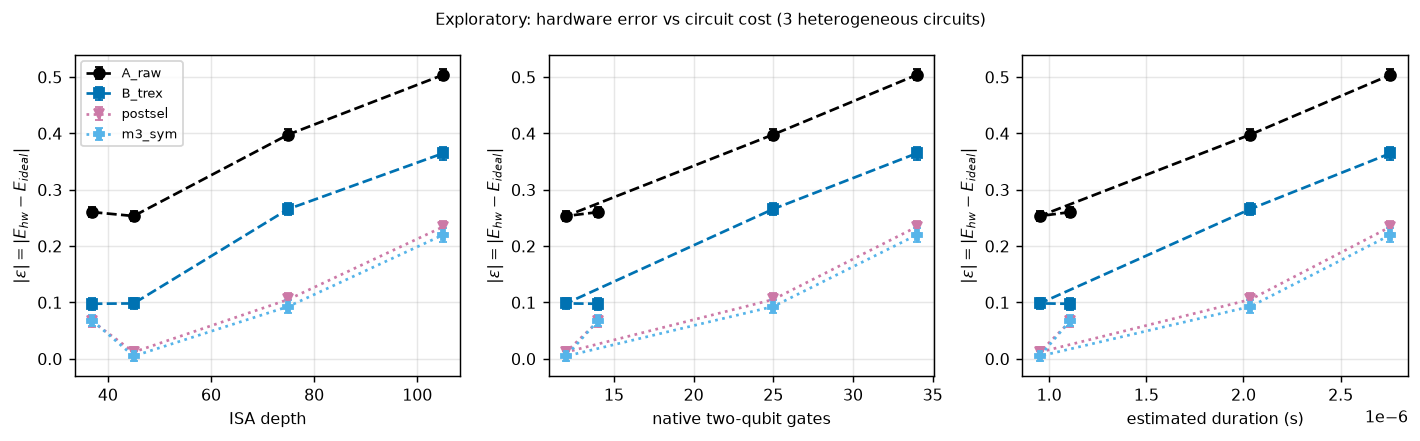

In [37]:
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi":130, "savefig.dpi":300, "font.size":9,
                     "axes.grid":True, "grid.alpha":0.3})
CB = {"A_raw":"#000000","B_trex":"#0072B2","C_zne":"#D55E00",
      "D_suppression":"#009E73","postsel":"#CC79A7","m3_sym":"#56B4E9"}
MK = {"A_raw":"o","B_trex":"s","C_zne":"^","D_suppression":"D","postsel":"v","m3_sym":"P"}

def fig_depth_vs_error(analysis, res, fname="fig6_depth_vs_error"):
    if not len(analysis): print("skipped (no hardware data)"); return
    fig, axes = plt.subplots(1, 3, figsize=(11, 3.4))
    xs = [("ISA_depth","ISA depth"), ("n_2q","native two-qubit gates"),
          ("est_duration_s","estimated duration (s)")]
    for ax, (col, lab) in zip(axes, xs):
        for arm in analysis.index.get_level_values(0).unique():
            sub = analysis.loc[arm]
            ax.errorbar([res.loc[k, col] for k in sub.index], sub["abs_epsilon"],
                        yerr=sub["stderr"], marker=MK.get(arm,"o"), ls="--", capsize=2,
                        color=CB.get(arm,"grey"), label=arm)
        # post-selected and M3+symmetry stages carry their own markers (section 13)
        if SAMPLER_TABLE is not None and len(SAMPLER_TABLE):
            for stage, ecol, scol in (("postsel","E_postsel","sd_postsel"),
                                      ("m3_sym","E_m3_sym","sd_m3_sym")):
                if ecol not in SAMPLER_TABLE: continue
                ks = [k for k in SAMPLER_TABLE.index if k in res.index]
                ax.errorbar([res.loc[k, col] for k in ks],
                            [abs(SAMPLER_TABLE.loc[k, ecol] - IDEAL.loc[k,"E_ideal"]) for k in ks],
                            yerr=[SAMPLER_TABLE.loc[k, scol] if scol in SAMPLER_TABLE else None
                                  for k in ks],
                            marker=MK[stage], ls=":", capsize=2, color=CB[stage], label=stage)
        ax.set_xlabel(lab); ax.set_ylabel(r"$|\epsilon| = |E_{hw}-E_{ideal}|$")
    axes[0].legend(fontsize=7)
    fig.suptitle("Exploratory: hardware error vs circuit cost (3 heterogeneous circuits)", fontsize=9)
    fig.tight_layout(); fig.savefig(f"{OUTDIR}/{fname}.png"); fig.savefig(f"{OUTDIR}/{fname}.pdf")
    plt.show()

fig_depth_vs_error(ANALYSIS, RES)

## 15. Figures

Every energy figure carries the exact ground-state line and, where relevant, the RBS ideal ceiling. Colours are colour-blind safe (Okabe-Ito).

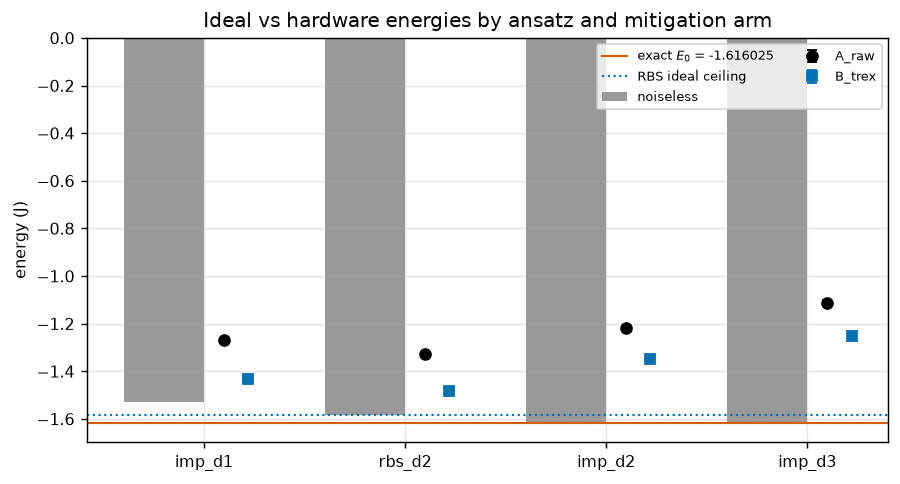

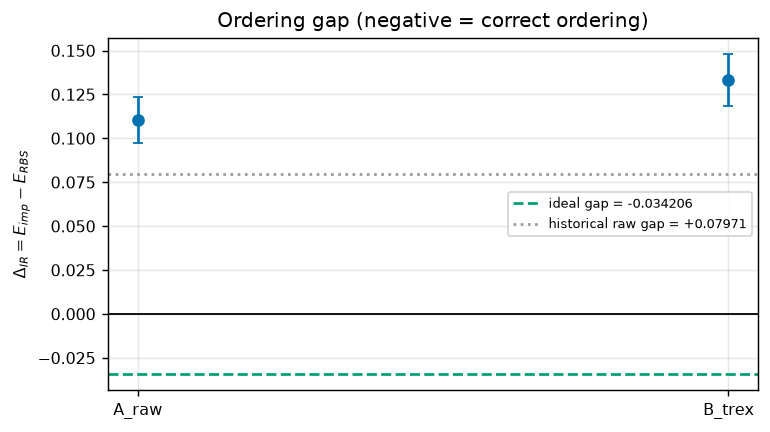

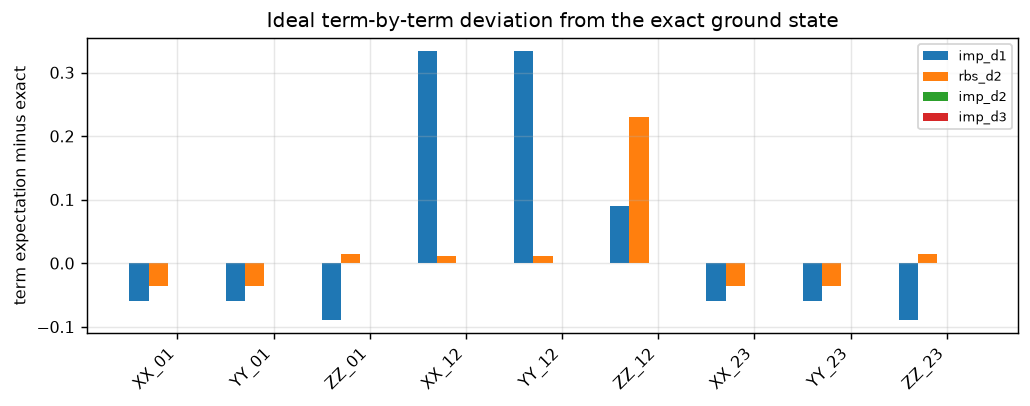

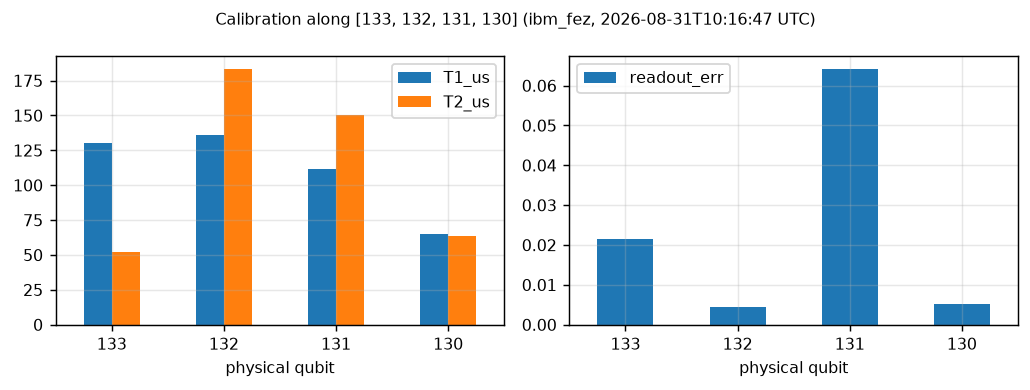

In [38]:
def fig_ideal_vs_hw(analysis, fname="fig1_ideal_vs_hardware"):
    fig, ax = plt.subplots(figsize=(7, 3.8))
    x = np.arange(len(PRIMARY))
    ax.bar(x - 0.2, [IDEAL.loc[k,"E_ideal"] for k in PRIMARY], 0.4,
           label="noiseless", color="#999999")
    if len(analysis):
        for i, arm in enumerate(analysis.index.get_level_values(0).unique()):
            sub = analysis.loc[arm]
            ax.errorbar(x + 0.1 + 0.12*i, [sub.loc[k,"E_hw"] for k in PRIMARY],
                        yerr=[sub.loc[k,"stderr"] for k in PRIMARY], ls="none",
                        marker=MK.get(arm,"o"), color=CB.get(arm,"grey"), capsize=3, label=arm)
    ax.axhline(E0, color="#D55E00", ls="-", lw=1.2, label=f"exact $E_0$ = {E0:.6f}")
    ax.axhline(IDEAL.loc["rbs_d2","E_ideal"], color="#0072B2", ls=":", lw=1.2,
               label="RBS ideal ceiling")
    ax.set_xticks(x); ax.set_xticklabels(PRIMARY); ax.set_ylabel("energy (J)")
    ax.set_title("Ideal vs hardware energies by ansatz and mitigation arm")
    ax.legend(fontsize=7, ncol=2); fig.tight_layout()
    fig.savefig(f"{OUTDIR}/{fname}.png"); fig.savefig(f"{OUTDIR}/{fname}.pdf"); plt.show()

def fig_ordering(ordering, fname="fig3_ordering_gap"):
    fig, ax = plt.subplots(figsize=(6, 3.4))
    ideal_gap = IDEAL.loc["imp_d2","E_ideal"] - IDEAL.loc["rbs_d2","E_ideal"]
    ax.axhline(0, color="k", lw=1); ax.axhline(ideal_gap, color="#009E73", ls="--",
               label=f"ideal gap = {ideal_gap:+.6f}")
    if len(ordering):
        ax.errorbar(range(len(ordering)), ordering["gap_hw"], yerr=ordering["gap_sd"],
                    marker="o", ls="none", capsize=3, color="#0072B2")
        ax.set_xticks(range(len(ordering))); ax.set_xticklabels(ordering.index)
    hg = HISTORICAL_RAW[("A_raw","imp_d2")][0] - HISTORICAL_RAW[("A_raw","rbs_d2")][0]
    ax.axhline(hg, color="#999999", ls=":", label=f"historical raw gap = {hg:+.5f}")
    ax.set_ylabel(r"$\Delta_{IR}=E_{imp}-E_{RBS}$")
    ax.set_title("Ordering gap (negative = correct ordering)")
    ax.legend(fontsize=7); fig.tight_layout()
    fig.savefig(f"{OUTDIR}/{fname}.png"); fig.savefig(f"{OUTDIR}/{fname}.pdf"); plt.show()

def fig_hardware_terms(analysis, fname="fig5b_hardware_terms"):
    """Term-by-term hardware error, available because all nine terms ride in the same PUB."""
    recs = [(a, k, v) for (a, k), v in EST_RAW.items()
            if not k.startswith("_") and v.get("terms")]
    if not recs: print("fig5b skipped: no term-resolved hardware data"); return
    fig, ax = plt.subplots(figsize=(9, 3.4))
    w = 0.8/len(recs)
    for i, (arm, key, v) in enumerate(recs):
        ideal = IDEAL_TERMS.loc[key]
        ax.bar(np.arange(len(TERM_LABELS)) + i*w - 0.4,
               [v["terms"][t] - ideal[t] for t in TERM_LABELS], w,
               yerr=[v["term_stderr"].get(t) for t in TERM_LABELS], capsize=2,
               label=f"{arm}/{key}")
    ax.axhline(0, color="k", lw=1)
    ax.set_xticks(range(len(TERM_LABELS))); ax.set_xticklabels(TERM_LABELS, rotation=45, ha="right")
    ax.set_ylabel("hardware minus ideal"); ax.legend(fontsize=6, ncol=2)
    ax.set_title("Term-by-term hardware error (stability check across the nine bond terms)")
    save_fig(fig, fname)

def fig_ideal_terms(fname="fig5_ideal_terms"):
    fig, ax = plt.subplots(figsize=(8, 3.2))
    T = IDEAL_TERMS.drop(columns=["sum/4"])
    exact = pd.Series(term_expectations(GS))
    w = 0.8/len(T)
    for i, k in enumerate(T.index):
        ax.bar(np.arange(len(T.columns)) + i*w - 0.4, (T.loc[k] - exact).values, w, label=k)
    ax.set_xticks(range(len(T.columns))); ax.set_xticklabels(T.columns, rotation=45, ha="right")
    ax.set_ylabel("term expectation minus exact"); ax.legend(fontsize=7)
    ax.set_title("Ideal term-by-term deviation from the exact ground state")
    fig.tight_layout(); fig.savefig(f"{OUTDIR}/{fname}.png", dpi=300)
    fig.savefig(f"{OUTDIR}/{fname}.pdf"); plt.show()

def fig_calibration(fname="fig10_calibration"):
    if QTAB.isna().all().all(): print("no calibration data"); return
    fig, ax = plt.subplots(1, 2, figsize=(8, 3))
    for a, cols in zip(ax, (["T1_us","T2_us"], ["readout_err"])):
        cols = [c for c in cols if c in QTAB]
        if cols: QTAB[cols].plot.bar(ax=a, rot=0)
        a.set_xlabel("physical qubit")
    fig.suptitle(f"Calibration along {PHYSICAL_QUBITS} ({CAL['backend']}, {CAL['retrieved_utc'][:19]} UTC)",
                 fontsize=9)
    fig.tight_layout(); fig.savefig(f"{OUTDIR}/{fname}.png", dpi=300)
    fig.savefig(f"{OUTDIR}/{fname}.pdf"); plt.show()

fig_ideal_vs_hw(ANALYSIS); fig_ordering(ORDERING); fig_ideal_terms(); fig_calibration()

### Remaining figures

The figures distinguish direct signed M3 estimates from optional nearest-positive-probability estimates. D2/D3 plots display both target-state equivalence and compiled-resource separation. Figures requiring hardware results print a skip notice rather than fabricating data.


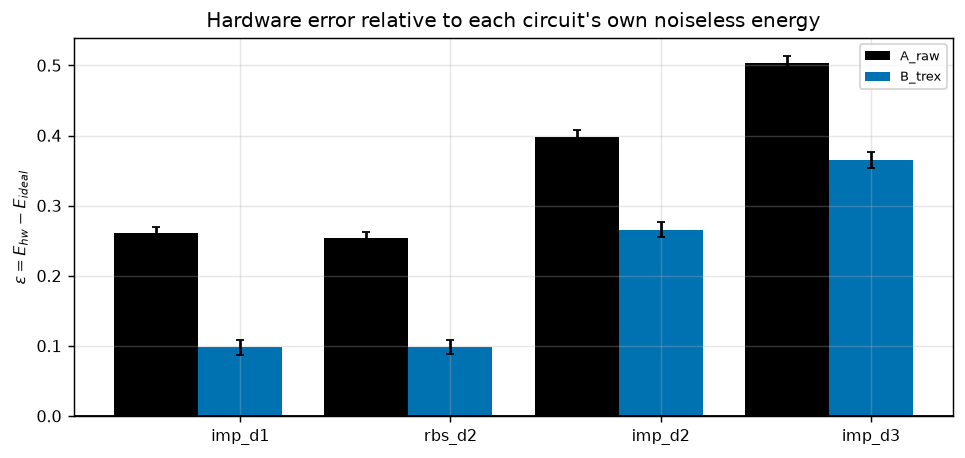

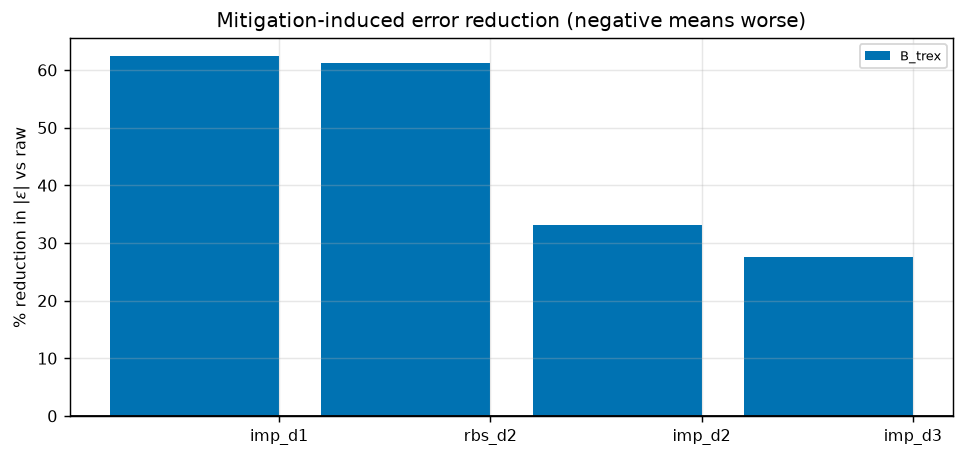

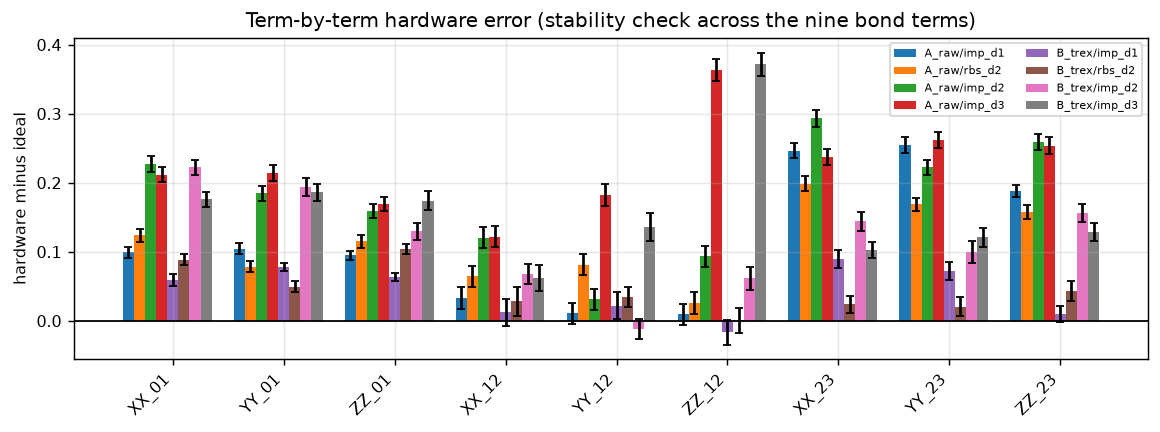

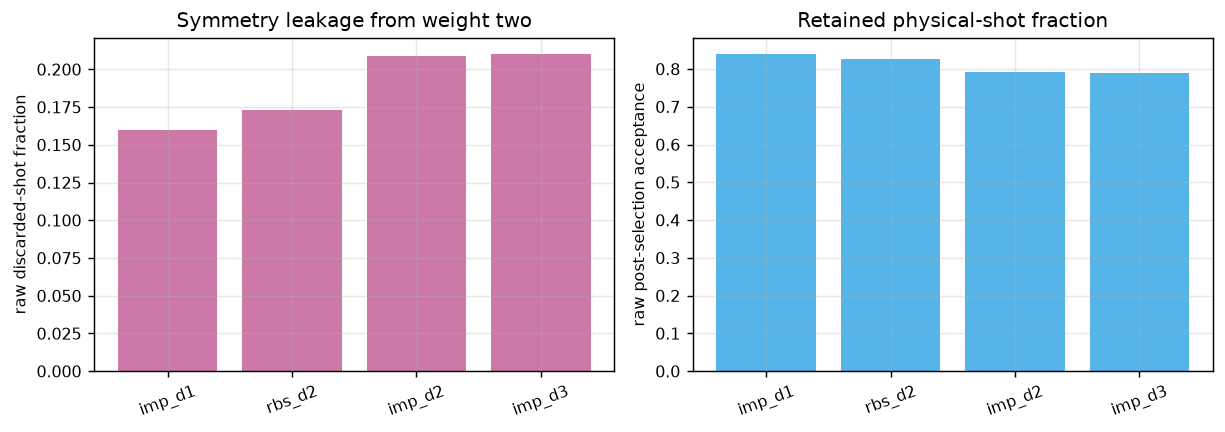

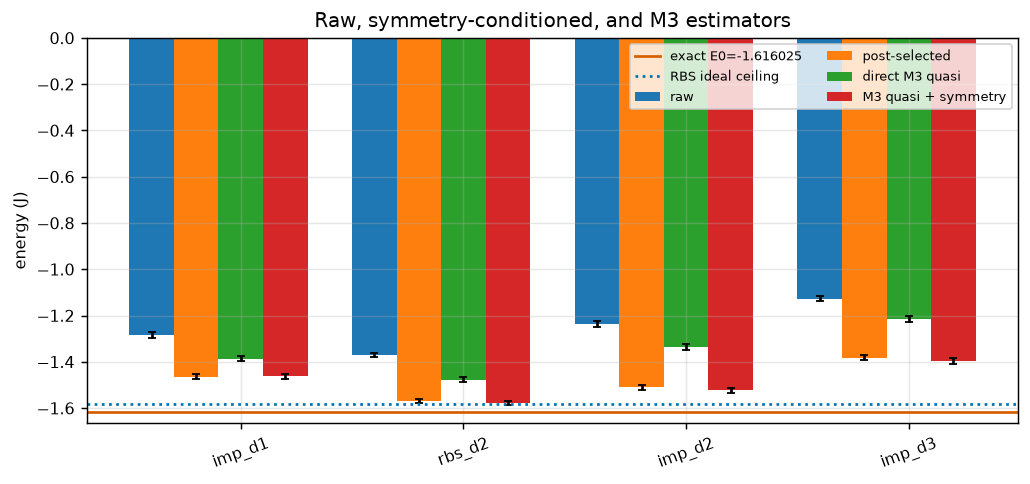

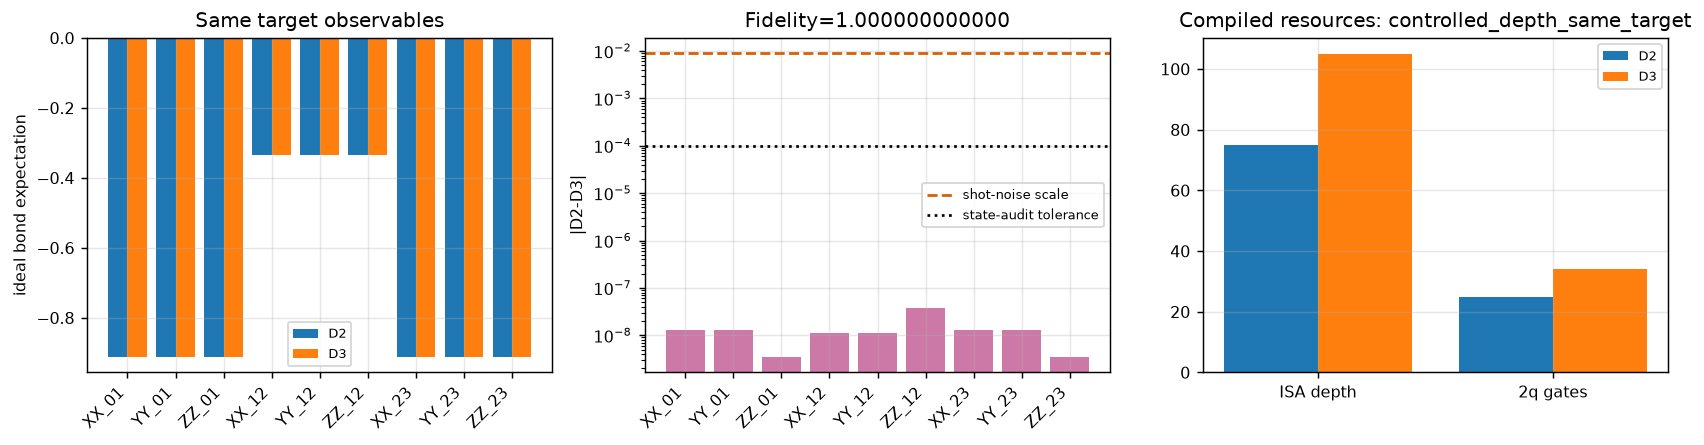

In [39]:
def save_fig(fig, name):
    fig.tight_layout()
    fig.savefig(f"{OUTDIR}/{name}.png", dpi=300)
    fig.savefig(f"{OUTDIR}/{name}.pdf")
    plt.show()

def fig2_error_vs_own_ideal(analysis, fname="fig2_error_vs_own_ideal"):
    if not len(analysis):
        print("fig2 skipped: no hardware data"); return
    fig, ax = plt.subplots(figsize=(7.5, 3.6))
    arms = list(analysis.index.get_level_values(0).unique())
    w = 0.8/len(arms)
    for i, arm in enumerate(arms):
        sub = analysis.loc[arm]
        keys = [k for k in PRIMARY if k in sub.index]
        ax.bar(np.arange(len(keys)) + i*w - 0.4,
               [sub.loc[k, "epsilon"] for k in keys], w,
               yerr=[sub.loc[k, "stderr"] for k in keys], capsize=2,
               color=CB.get(arm, "grey"), label=arm)
    ax.axhline(0, color="k", lw=1)
    ax.set_xticks(range(len(PRIMARY))); ax.set_xticklabels(PRIMARY)
    ax.set_ylabel(r"$\epsilon=E_{hw}-E_{ideal}$")
    ax.set_title("Hardware error relative to each circuit's own noiseless energy")
    ax.legend(fontsize=7); save_fig(fig, fname)

def fig4_pct_reduction(analysis, fname="fig4_pct_error_reduction"):
    if not len(analysis):
        print("fig4 skipped: no hardware data"); return
    sub = analysis[analysis.index.get_level_values(0) != "A_raw"]
    if not len(sub):
        print("fig4 skipped: raw arm only"); return
    fig, ax = plt.subplots(figsize=(7.5, 3.6))
    arms = list(sub.index.get_level_values(0).unique())
    w = 0.8/len(arms)
    for i, arm in enumerate(arms):
        d = sub.loc[arm]
        keys = [k for k in PRIMARY if k in d.index]
        ax.bar(np.arange(len(keys)) + i*w - 0.4,
               [d.loc[k, "pct_gap_closure"] for k in keys], w,
               color=CB.get(arm, "grey"), label=arm)
    ax.axhline(0, color="k", lw=1)
    ax.set_xticks(range(len(PRIMARY))); ax.set_xticklabels(PRIMARY)
    ax.set_ylabel(r"% reduction in $|\epsilon|$ vs raw")
    ax.set_title("Mitigation-induced error reduction (negative means worse)")
    ax.legend(fontsize=7); save_fig(fig, fname)

def fig7_leakage(sampler_table, fname="fig7_leakage_acceptance"):
    if sampler_table is None or not len(sampler_table):
        print("fig7 skipped: no Sampler data"); return
    fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.4))
    axes[0].bar(sampler_table.index, sampler_table["discard_frac"], color=CB["postsel"])
    axes[0].set_ylabel("raw discarded-shot fraction")
    axes[0].set_title("Symmetry leakage from weight two")
    axes[1].bar(sampler_table.index, sampler_table["acceptance"], color=CB["m3_sym"])
    axes[1].set_ylabel("raw post-selection acceptance")
    axes[1].set_title("Retained physical-shot fraction")
    for ax in axes: ax.tick_params(axis="x", rotation=20)
    save_fig(fig, fname)

def fig8_stages(sampler_table, fname="fig8_postselection_stages"):
    if sampler_table is None or not len(sampler_table):
        print("fig8 skipped: no Sampler data"); return
    stages = [
        ("E_raw", "sd_raw", "raw"),
        ("E_postsel", "sd_postsel", "post-selected"),
        ("E_m3_quasi", "sd_m3_quasi", "direct M3 quasi"),
        ("E_m3_sym", "sd_m3_sym", "M3 quasi + symmetry"),
        ("E_m3_nearest", "sd_m3_nearest", "M3 nearest probability"),
    ]
    stages = [s for s in stages if s[0] in sampler_table]
    fig, ax = plt.subplots(figsize=(8, 3.8))
    w = 0.8/max(len(stages), 1)
    for i, (energy_col, sd_col, label) in enumerate(stages):
        error = sampler_table[sd_col] if sd_col in sampler_table else None
        ax.bar(np.arange(len(sampler_table)) + i*w - 0.4,
               sampler_table[energy_col], w, label=label, yerr=error, capsize=2)
    ax.axhline(E0, color="#D55E00", label=f"exact E0={E0:.6f}")
    ax.axhline(IDEAL.loc["rbs_d2", "E_ideal"], color="#0072B2", ls=":",
               label="RBS ideal ceiling")
    ax.set_xticks(range(len(sampler_table)))
    ax.set_xticklabels(sampler_table.index, rotation=20)
    ax.set_ylabel("energy (J)")
    ax.set_title("Raw, symmetry-conditioned, and M3 estimators")
    ax.legend(fontsize=7, ncol=2); save_fig(fig, fname)

def fig9_d2_d3(fname="fig9_d2_vs_d3_controlled_depth"):
    fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
    terms = list(t2)
    axes[0].bar(np.arange(len(terms))-0.2, [t2[k] for k in terms], 0.4, label="D2")
    axes[0].bar(np.arange(len(terms))+0.2, [t3[k] for k in terms], 0.4, label="D3")
    axes[0].set_xticks(range(len(terms)))
    axes[0].set_xticklabels(terms, rotation=45, ha="right")
    axes[0].set_ylabel("ideal bond expectation")
    axes[0].set_title("Same target observables")
    axes[0].legend(fontsize=7)

    diffs = [abs(t2[k]-t3[k]) for k in terms]
    axes[1].bar(range(len(terms)), diffs, color="#CC79A7")
    axes[1].axhline(SHOT_NOISE_FLOOR, color="#D55E00", ls="--", label="shot-noise scale")
    axes[1].axhline(TOL_OBS, color="k", ls=":", label="state-audit tolerance")
    axes[1].set_yscale("log")
    axes[1].set_xticks(range(len(terms)))
    axes[1].set_xticklabels(terms, rotation=45, ha="right")
    axes[1].set_ylabel("|D2-D3|")
    axes[1].set_title(f"Fidelity={fid23:.12f}")
    axes[1].legend(fontsize=7)

    resource_names = ["ISA_depth", "n_2q"]
    x = np.arange(len(resource_names))
    axes[2].bar(x-0.2, [RES.loc["imp_d2", c] for c in resource_names], 0.4, label="D2")
    axes[2].bar(x+0.2, [RES.loc["imp_d3", c] for c in resource_names], 0.4, label="D3")
    axes[2].set_xticks(x); axes[2].set_xticklabels(["ISA depth", "2q gates"])
    axes[2].set_title(f"Compiled resources: {D3_USE_CASE}")
    axes[2].legend(fontsize=7)
    save_fig(fig, fname)

fig2_error_vs_own_ideal(ANALYSIS)
fig4_pct_reduction(ANALYSIS)
fig_hardware_terms(ANALYSIS)
fig7_leakage(SAMPLER_TABLE)
fig8_stages(SAMPLER_TABLE)
fig9_d2_d3()


## 16. Persistent results and safe reload

The corrected notebook uses its own `results_corrected/` directory so it cannot mistake job IDs from the earlier notebook for jobs with a different PUB list.

Every Runtime job ID is written atomically immediately after submission. M3 calibration matrices are saved to a JSON calibration file. `reload_all()` only reloads jobs and calibration files; it never submits or refreshes calibration data.


In [40]:
EXPORT = {
    "backend": CAL,
    "ideal": IDEAL.reset_index().to_dict("records"),
    "ideal_terms": IDEAL_TERMS.reset_index().to_dict("records"),
    "resources": RES.reset_index().to_dict("records"),
    "frozen_parameters": FROZEN,
    "d2_d3_audit": {
        "fidelity": fid23,
        "phase_aligned_norm_distance": norm_dist,
        "energy_difference": abs(e2-e3),
        "max_observable_difference": max_obs,
        "state_equivalent": STATE_EQUIVALENT,
        "resources_distinct": D3_RESOURCE_DISTINCT,
        "use_case": D3_USE_CASE,
        "included": INCLUDE_D3,
    },
    "primary_hardware_circuits": PRIMARY,
    "final_measurement_mappings": RESULT_MAPPINGS,
    "estimator_job_ids": ESTIMATOR_JOB_IDS,
    "sampler_job_ids": SAMPLER_JOB_IDS,
    "m3_job_ids": M3_JOB_IDS,
    "batch_ids": BATCH_IDS,
    "plan": PLAN.reset_index().to_dict("records"),
    "exact": {"E0": E0, "gap": GAP},
}
save_json_file(os.path.join(OUTDIR, "study_metadata.json"), EXPORT)
IDEAL.to_csv(os.path.join(OUTDIR, "ideal_results.csv"))
IDEAL_TERMS.to_csv(os.path.join(OUTDIR, "ideal_terms.csv"))
RES.to_csv(os.path.join(OUTDIR, "transpilation_resources.csv"))
PLAN.to_csv(os.path.join(OUTDIR, "submission_plan.csv"))
print("exported deterministic analysis to", OUTDIR)

def reload_all():
    """Reload saved Estimator, Sampler, and M3 data. Never submits any workload."""
    global EST_RAW, ANALYSIS, ORDERING, SAMPLER_COUNTS, SAMPLER_TABLE, PER_SETTING, M3_MIT, RESULT_MAPPINGS
    if SERVICE is None:
        print("No IBM service is available; nothing remote can be reloaded.")
        return None

    if ESTIMATOR_JOB_IDS:
        EST_RAW = load_estimator_results(ESTIMATOR_JOB_IDS)
        ANALYSIS = analysis_table(EST_RAW)
        ORDERING = ordering_table(EST_RAW)

    SAMPLER_COUNTS = {}
    RESULT_MAPPINGS = dict(SAMP_MAPPINGS)
    if "main" in SAMPLER_JOB_IDS:
        saved = SAMPLER_JOB_IDS["main"]
        for label, mapping in saved.get("mappings", {}).items():
            if isinstance(mapping, dict):
                RESULT_MAPPINGS[label] = {int(k): int(v) for k, v in mapping.items()}
            else:
                RESULT_MAPPINGS[label] = mapping
        result = SERVICE.job(saved["job_id"]).result()
        labels = saved.get("labels", SAMP_LABELS)
        for pub_result, label in zip(result, labels):
            key, setting = label.split("|")
            SAMPLER_COUNTS.setdefault(key, {})[setting] = counts_from_pub_result(pub_result)

    if os.path.exists(M3_CAL_FILE):
        if not M3_AVAILABLE:
            raise RuntimeError("mthree is unavailable")
        M3_MIT = mthree.M3Mitigation(BACKEND)
        M3_MIT.cals_from_file(M3_CAL_FILE)

    SAMPLER_TABLE = analyse_sampler(SAMPLER_COUNTS, M3_MIT, RESULT_MAPPINGS) if SAMPLER_COUNTS else None
    PER_SETTING = per_setting_report(SAMPLER_COUNTS, M3_MIT, RESULT_MAPPINGS) if SAMPLER_COUNTS else None
    return {"estimator": ANALYSIS, "ordering": ORDERING, "sampler": SAMPLER_TABLE}

print("reload_all() is read-only: it never invokes estimator.run, sampler.run, or cals_from_system")


exported deterministic analysis to results_corrected
reload_all() is read-only: it never invokes estimator.run, sampler.run, or cals_from_system


## 17. Interpretation framework

| channel | diagnostic |
|---|---|
| ansatz expressibility | noiseless $E-E_0$, fidelity, and variance |
| gate/depth error | circuit-specific $\epsilon$ versus ISA depth, 2q count, and duration |
| controlled depth | Improved D2 versus D3 only when they share the ideal target but differ physically |
| readout error | strict raw versus TREX; raw Sampler versus direct M3 |
| symmetry leakage | observed Hamming-weight-two rejection fraction |
| mitigation bias | overshoot below $E_0$, unstable bond terms, or larger $|\epsilon|$ |
| calibration drift | job execution spans, properties, calibration timestamp, and batch ID |
| statistical uncertainty | Estimator standard errors and count/M3 bootstrap |

A lower numerical energy is not automatically better. Improvement requires a smaller circuit-specific $|\epsilon|$ with uncertainty, stable term-level behavior, and no unphysical overshoot.

Batch execution keeps the jobs close in time but does not guarantee an unchanged calibration. The notebook therefore records provenance instead of claiming a perfectly fixed calibration window.


### Auto-generated conclusions

The conclusions below are generated only from available data. Missing hardware branches are labelled `PENDING`. The D3 conclusion separately reports target-state equivalence and compiled-resource distinctness, preventing state redundancy from being confused with circuit-depth redundancy.


In [41]:
def conclusions():
    out = []
    have_est = len(ANALYSIS) > 0
    have_arm = lambda arm: have_est and arm in ANALYSIS.index.get_level_values(0)
    have_samp = SAMPLER_TABLE is not None and len(SAMPLER_TABLE) > 0

    if have_arm("A_raw"):
        g = ORDERING.loc["A_raw"]
        out.append(("1. Raw ordering reversal reproduced?",
                    f"{'YES' if g.gap_hw > 0 else 'NO'}; gap {g.gap_hw:+.6f} +/- {g.gap_sd:.6f}, "
                    f"z={g.z_vs_zero:+.2f}."))
    else:
        out.append(("1. Raw ordering reversal reproduced?", "PENDING: strict raw arm not loaded."))

    if have_arm("B_trex") and have_arm("A_raw"):
        b = ANALYSIS.loc["B_trex"]
        text = ", ".join(f"{k}: {b.loc[k,'pct_gap_closure']:+.1f}%" for k in b.index)
        out.append(("2. TREX error reduction?", text))
    else:
        out.append(("2. TREX error reduction?", "PENDING: raw and TREX arms are both required."))

    if have_arm("C_zne") and have_arm("A_raw"):
        c = ANALYSIS.loc["C_zne"]
        text = ", ".join(f"{k}: {c.loc[k,'pct_gap_closure']:+.1f}%" for k in c.index)
        out.append(("3. ZNE error reduction?", text))
    else:
        out.append(("3. ZNE error reduction?", "PENDING: ZNE arm not loaded."))

    if have_samp and {"rbs_d2", "imp_d2"}.issubset(SAMPLER_TABLE.index):
        gap = SAMPLER_TABLE.loc["imp_d2", "E_postsel"] - SAMPLER_TABLE.loc["rbs_d2", "E_postsel"]
        sd = float(np.hypot(SAMPLER_TABLE.loc["imp_d2", "sd_postsel"],
                            SAMPLER_TABLE.loc["rbs_d2", "sd_postsel"]))
        out.append(("4. Symmetry post-selection restored ordering?",
                    f"{'YES' if gap < 0 else 'NO'}; post-selected gap {gap:+.6f} +/- {sd:.6f}."))
    else:
        out.append(("4. Symmetry post-selection restored ordering?", "PENDING: Sampler data not loaded."))

    if have_samp:
        text = ", ".join(
            f"{k}: {100*SAMPLER_TABLE.loc[k,'discard_frac']:.1f}% discarded"
            for k in SAMPLER_TABLE.index
        )
        out.append(("5. Observed symmetry leakage?", text))
    else:
        out.append(("5. Observed symmetry leakage?", "PENDING: Sampler data not loaded."))

    if STATE_EQUIVALENT and D3_RESOURCE_DISTINCT:
        d_depth = int(RES.loc["imp_d3", "ISA_depth"] - RES.loc["imp_d2", "ISA_depth"])
        d_2q = int(RES.loc["imp_d3", "n_2q"] - RES.loc["imp_d2", "n_2q"])
        out.append(("6. D2/D3 controlled-depth status?",
                    f"VALID CONTROL: target fidelity {fid23:.12f}; D3 adds {d_depth} ISA-depth "
                    f"and {d_2q} two-qubit gates on {BACKEND.name}. Included={INCLUDE_D3}."))
    elif STATE_EQUIVALENT:
        out.append(("6. D2/D3 controlled-depth status?",
                    "REDUNDANT: target state and compiled resources are both equivalent."))
    else:
        out.append(("6. D2/D3 controlled-depth status?",
                    f"NOT A CLEAN DEPTH CONTROL: use case is {D3_USE_CASE}."))

    if have_arm("A_raw") and INCLUDE_D3:
        d2 = ANALYSIS.loc[("A_raw", "imp_d2")]
        d3 = ANALYSIS.loc[("A_raw", "imp_d3")]
        excess = d3.epsilon - d2.epsilon
        sd = float(np.hypot(d2.stderr, d3.stderr))
        out.append(("7. Extra raw error from deeper D3 implementation?",
                    f"epsilon(D3)-epsilon(D2)={excess:+.6f} +/- {sd:.6f}."))
    else:
        out.append(("7. Extra raw error from deeper D3 implementation?",
                    "PENDING: requires D3 inclusion and the raw arm."))

    out.append(("8. Next scale?",
                "After the L=4 mitigation and same-target depth control, move to L=6 for a true "
                "expressibility-versus-depth study where optimized depths remain ideally distinct."))
    return out

print("="*100)
for question, answer in conclusions():
    print(f"\n{question}\n    {answer}")
print("\n" + "="*100)
save_json_file(os.path.join(OUTDIR, "conclusions.json"), dict(conclusions()))



1. Raw ordering reversal reproduced?
    YES; gap +0.110352 +/- 0.013005, z=+8.49.

2. TREX error reduction?
    imp_d1: +62.5%, rbs_d2: +61.2%, imp_d2: +33.2%, imp_d3: +27.6%

3. ZNE error reduction?
    PENDING: ZNE arm not loaded.

4. Symmetry post-selection restored ordering?
    NO; post-selected gap +0.059235 +/- 0.014947.

5. Observed symmetry leakage?
    imp_d1: 16.0% discarded, rbs_d2: 17.3% discarded, imp_d2: 20.9% discarded, imp_d3: 21.0% discarded

6. D2/D3 controlled-depth status?
    VALID CONTROL: target fidelity 1.000000000000; D3 adds 30 ISA-depth and 9 two-qubit gates on ibm_fez. Included=True.

7. Extra raw error from deeper D3 implementation?
    epsilon(D3)-epsilon(D2)=+0.105835 +/- 0.013572.

8. Next scale?
    After the L=4 mitigation and same-target depth control, move to L=6 for a true expressibility-versus-depth study where optimized depths remain ideally distinct.



## 18. References and API basis

- IBM Quantum primitives: https://quantum.cloud.ibm.com/docs/en/guides/qiskit-runtime-primitives
- Execution modes and Batch: https://quantum.cloud.ibm.com/docs/en/guides/execution-modes
- Run jobs in Batch: https://quantum.cloud.ibm.com/docs/en/guides/run-jobs-batch
- Estimator noise management, TREX and ZNE: https://quantum.cloud.ibm.com/docs/en/guides/estimator-noise-management
- Estimator options: https://quantum.cloud.ibm.com/docs/en/guides/estimator-options
- Workload usage estimation: https://quantum.cloud.ibm.com/docs/en/guides/estimate-job-run-time
- IBM Sampler readout mitigation with M3: https://quantum.cloud.ibm.com/docs/en/tutorials/readout-error-mitigation-sampler
- M3 final measurement mappings: https://qiskit.github.io/qiskit-addon-mthree/stubs/mthree.utils.final_measurement_mapping.html
- M3 calibration save/load: https://qiskit.github.io/qiskit-addon-mthree/cal_io.html
- M3 mitigation API and Runtime `runtime_mode`: https://qiskit.github.io/qiskit-addon-mthree/stubs/mthree.M3Mitigation.html
- T. Nation et al., *Scalable Mitigation of Measurement Errors on Quantum Computers*, PRX Quantum 2, 040326 (2021)
- E. van den Berg et al., *Model-free readout-error mitigation*, Phys. Rev. A 105, 032620 (2022)

Record the package versions printed in section 2 with every reported hardware result. The notebook was designed against Qiskit 2.5.x, qiskit-ibm-runtime 0.49.x, and M3 3.0.x, while retaining public-API fallbacks where practical.
